# Newborn Weight Prediction Model

**Author:** Enrico Ceci

**Date:** 2025-10-28

*Note: this notebook was developed in R

In [1]:
# DATASET IMPORT

file_id = "1ChfwftuOSH-WLIto_1AvV-_sQIksGeTq"

download_url = paste0(
  "https://drive.google.com/uc?export=download&id=",
  file_id
)

download.file(
  download_url,
  destfile = "neonati.csv",
  mode = "wb"
)

nb_data = read.csv("neonati.csv", stringsAsFactors = TRUE)

In [2]:
# PRINT DATASET SAMPLE

head(nb_data)

,Anni.madre,N.gravidanze,Fumatrici,Gestazione,Peso,Lunghezza,Cranio,Tipo.parto,Ospedale,Sesso
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<fct>,<fct>,<fct>
1,26,0,0,42,3380,490,325,Nat,osp3,M
2,21,2,0,39,3150,490,345,Nat,osp1,F
3,34,3,0,38,3640,500,375,Nat,osp2,M
4,28,1,0,41,3690,515,365,Nat,osp2,M
5,20,0,0,38,3700,480,335,Nat,osp3,F
6,32,0,0,40,3200,495,340,Nat,osp2,F


In [3]:
# CHECK NUMBER OF ROWS IN DATASET

N <- nrow(nb_data)

print(N)

[1] 2500


In [5]:
# INSTALL PACKAGES, IF NEEDED

if (!requireNamespace("moments", quietly = TRUE)) {install.packages("moments")}

if (!requireNamespace("car", quietly = TRUE)) {install.packages("car")}

if (!requireNamespace("lmtest", quietly = TRUE)) {install.packages("lmtest")}

if (!requireNamespace("ggpubr", quietly = TRUE)) {install.packages("ggpubr")}

if (!requireNamespace("knitr", quietly = TRUE)) {install.packages("knitr")}

if (!requireNamespace("sandwich", quietly = TRUE)) {install.packages("sandwich")}

In [6]:
# IMPORT LIBRARIES

library(knitr)
library(moments)
library(car)
library(lmtest)
library(sandwich)

Loading required package: carData

Loading required package: zoo


Attaching package: ‘zoo’


The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric




# 1. Preliminary analysis

In this phase, we will explore the variables through descriptive analysis in order to understand their distributions and identify any outliers or anomalies.

In [7]:
kable(summary(nb_data))



|   |  Anni.madre  | N.gravidanze   |  Fumatrici    |  Gestazione  |     Peso    |  Lunghezza   |    Cranio  |Tipo.parto |Ospedale |Sesso  |
|:--|:-------------|:---------------|:--------------|:-------------|:------------|:-------------|:-----------|:----------|:--------|:------|
|   |Min.   : 0.00 |Min.   : 0.0000 |Min.   :0.0000 |Min.   :25.00 |Min.   : 830 |Min.   :310.0 |Min.   :235 |Ces: 728   |osp1:816 |F:1256 |
|   |1st Qu.:25.00 |1st Qu.: 0.0000 |1st Qu.:0.0000 |1st Qu.:38.00 |1st Qu.:2990 |1st Qu.:480.0 |1st Qu.:330 |Nat:1772   |osp2:849 |M:1244 |
|   |Median :28.00 |Median : 1.0000 |Median :0.0000 |Median :39.00 |Median :3300 |Median :500.0 |Median :340 |NA         |osp3:835 |NA     |
|   |Mean   :28.16 |Mean   : 0.9812 |Mean   :0.0416 |Mean   :38.98 |Mean   :3284 |Mean   :494.7 |Mean   :340 |NA         |NA       |NA     |
|   |3rd Qu.:32.00 |3rd Qu.: 1.0000 |3rd Qu.:0.0000 |3rd Qu.:40.00 |3rd Qu.:3620 |3rd Qu.:510.0 |3rd Qu.:350 |NA         |NA       |NA     |
|   |Max.  

The summary immediately highlights an anomaly in the data: the minimum value of the “Anni.madre” variable is 0. By inspecting the dataset, it becomes clear that observations 1380 and 1152 are affected by a data-entry error, with values of 0 and 1 respectively.

We will therefore impute the values 0 and 1 by replacing them with the mean calculated after excluding these two values.

In [8]:
# HANDLE ANOMALOUS VALUES FOR "Anni.madre"

# Calculate the mean excluding anomalous values
media_anni_madre = mean(
  nb_data$Anni.madre[!nb_data$Anni.madre %in% c(0, 1)],
  na.rm = TRUE
)

# Replace anomalous values with the mean
nb_data$Anni.madre[nb_data$Anni.madre %in% c(0, 1)] = media_anni_madre

attach(nb_data)

In [9]:
kable(summary(nb_data))



|   |  Anni.madre  | N.gravidanze   |  Fumatrici    |  Gestazione  |     Peso    |  Lunghezza   |    Cranio  |Tipo.parto |Ospedale |Sesso  |
|:--|:-------------|:---------------|:--------------|:-------------|:------------|:-------------|:-----------|:----------|:--------|:------|
|   |Min.   :13.00 |Min.   : 0.0000 |Min.   :0.0000 |Min.   :25.00 |Min.   : 830 |Min.   :310.0 |Min.   :235 |Ces: 728   |osp1:816 |F:1256 |
|   |1st Qu.:25.00 |1st Qu.: 0.0000 |1st Qu.:0.0000 |1st Qu.:38.00 |1st Qu.:2990 |1st Qu.:480.0 |1st Qu.:330 |Nat:1772   |osp2:849 |M:1244 |
|   |Median :28.00 |Median : 1.0000 |Median :0.0000 |Median :39.00 |Median :3300 |Median :500.0 |Median :340 |NA         |osp3:835 |NA     |
|   |Mean   :28.19 |Mean   : 0.9812 |Mean   :0.0416 |Mean   :38.98 |Mean   :3284 |Mean   :494.7 |Mean   :340 |NA         |NA       |NA     |
|   |3rd Qu.:32.00 |3rd Qu.: 1.0000 |3rd Qu.:0.0000 |3rd Qu.:40.00 |3rd Qu.:3620 |3rd Qu.:510.0 |3rd Qu.:350 |NA         |NA       |NA     |
|   |Max.  

In [10]:
# CALCULATE SKEWNESS AND KURTOSIS INDICES

# Define the function to calculate the indices
funzione_indici_forma <- function(x, nome_var) {
  data.frame(
    Variabile = nome_var,
    Skewness = round(skewness(x),2),
    Kurtosis = round(kurtosis(x)-3,2)
  )
}

# Select the variables of interest
vars <- nb_data[c("Anni.madre", "Peso", "Lunghezza", "Cranio", "Gestazione")]

# Calculate the indices for each variable, obtaining a list of vectors
results_list <- lapply(names(vars), function(n) funzione_indici_forma(vars[[n]], n))

# Convert the list into a table
kable(results_tab <- do.call(rbind, results_list))



|Variabile  | Skewness| Kurtosis|
|:----------|--------:|--------:|
|Anni.madre |     0.15|    -0.10|
|Peso       |    -0.65|     2.03|
|Lunghezza  |    -1.51|     6.49|
|Cranio     |    -0.79|     2.95|
|Gestazione |    -2.07|     8.26|

The response variable “Peso” is negatively skewed, although only slightly, indicating a slight prevalence of higher values, and it has a kurtosis coefficient > 0, therefore showing a leptokurtic distribution.

The variable that comes closest to the symmetry and kurtosis values of a normal distribution is “Anni.madre”, which is almost symmetric and slightly platykurtic.

“Cranio” shows a skewness of -0.79, while “Lunghezza” shows a more pronounced skewness, almost twice that of “Cranio”, with both variables displaying a leptokurtic shape (more pronounced for “Lunghezza”).

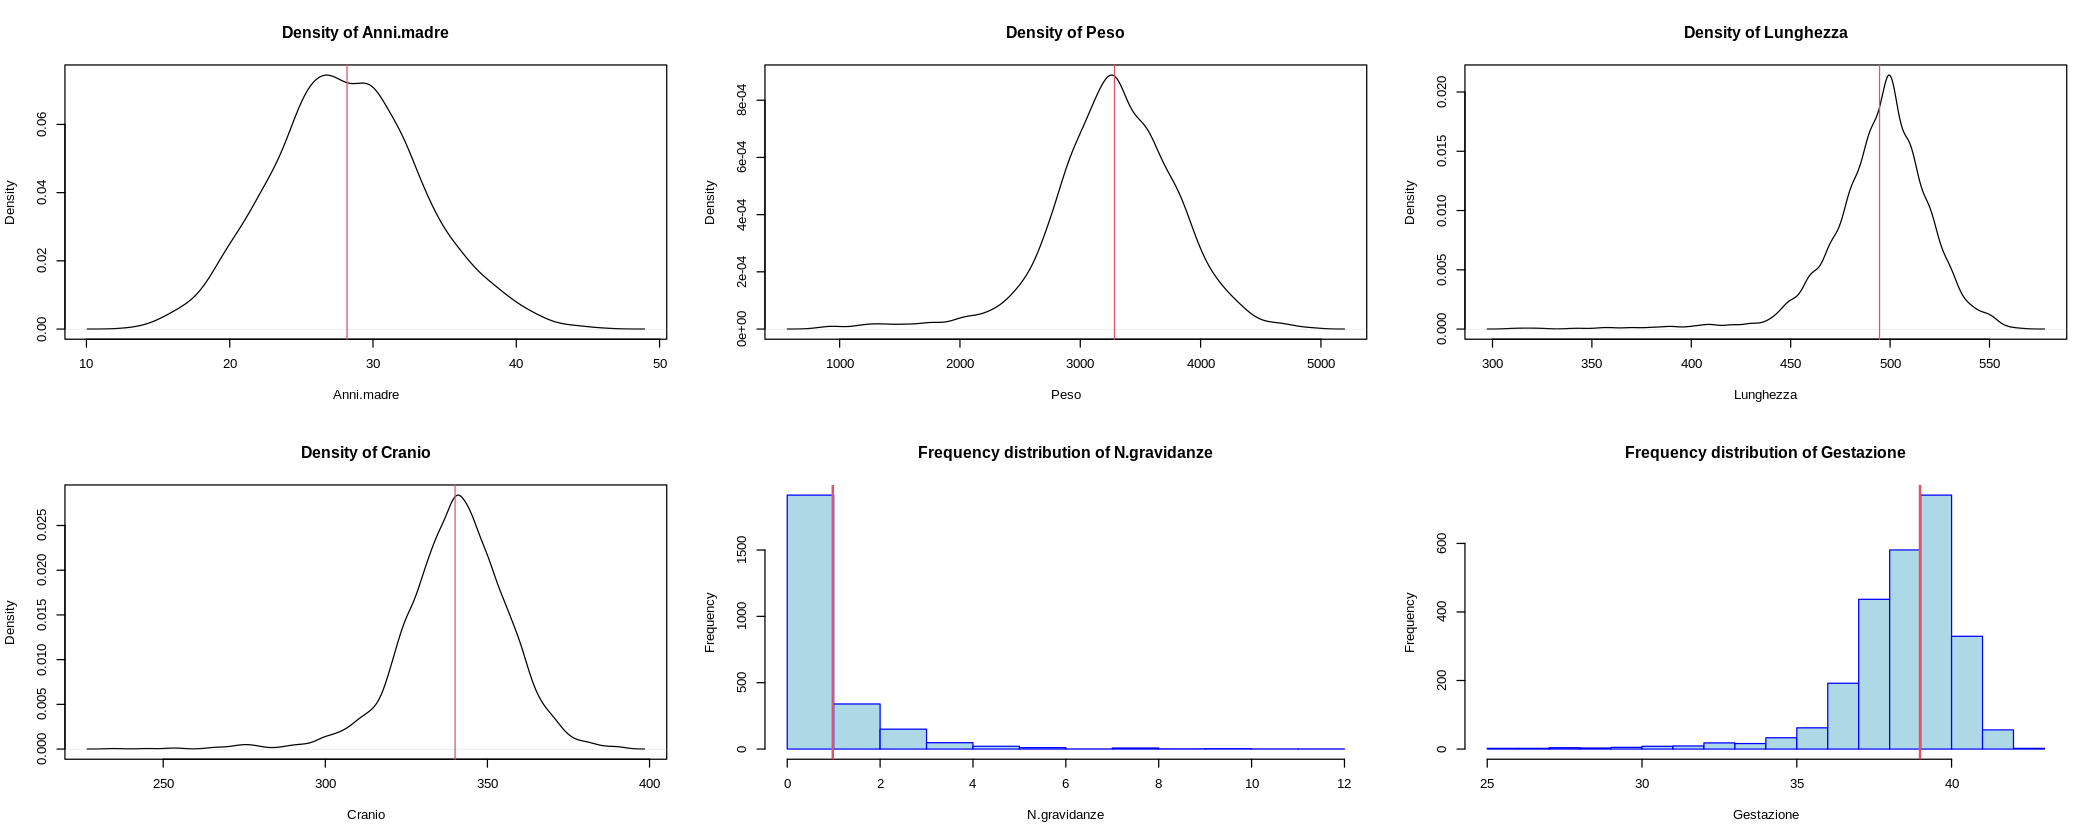

In [11]:
# DENSITY PLOTS

# Figure dimensions
options(
  repr.plot.width = 17.5,
  repr.plot.height = 7
)


# Plot generation
par(mfrow=c(2,3))

cont_vars = nb_data[c("Anni.madre", "Peso", "Lunghezza", "Cranio")]

for (cont_var in names(cont_vars)) {
  x = nb_data[[cont_var]]
  x = x[!is.na(x)]

  plot(density(x),
       main = paste("Density of", cont_var),
       xlab = cont_var)

  abline(v = mean(x), col = 2)
}


# Frequency distributions
disc_vars <- nb_data[c("N.gravidanze", "Gestazione")]

for (disc_var in names(disc_vars)) {
  x = nb_data[[disc_var]]
  x = x[!is.na(x)]

  hist(x,
       main = paste("Frequency distribution of", disc_var),
       xlab = disc_var,
       col = "lightblue",
       border = "blue")

  abline(v = mean(x), col = 2, lwd = 2)
}

The “Gestazione” variable shows marked negative skewness (-2.07), as do the “Peso”, “Cranio”, and “Lunghezza” variables, although to different degrees. Longer gestations are more prevalent in the dataset and tend to be associated with higher values of the anthropometric measurements. This association may contribute to the observed structure of the distributions, without, of course, allowing us to conclude that the skewness of “Gestazione” is directly responsible for that of the other variables.

## 1.1 Hypothesis testing using appropriate tests

### Hypothesis 1: Some hospitals perform more cesarean deliveries

In [14]:
# HYPOTHESIS 1 TEST

tabella.tipo_parto <- table(nb_data$Ospedale, nb_data$Tipo.parto)

df.tipo_parto <- as.data.frame(tabella.tipo_parto)
names(df.tipo_parto) <- c("Ospedale", "Tipo_Parto", "Frequence")

kable(tabella.tipo_parto <- table(nb_data$Ospedale, nb_data$Tipo.parto))



|     | Ces| Nat|
|:----|---:|---:|
|osp1 | 242| 574|
|osp2 | 254| 595|
|osp3 | 232| 603|

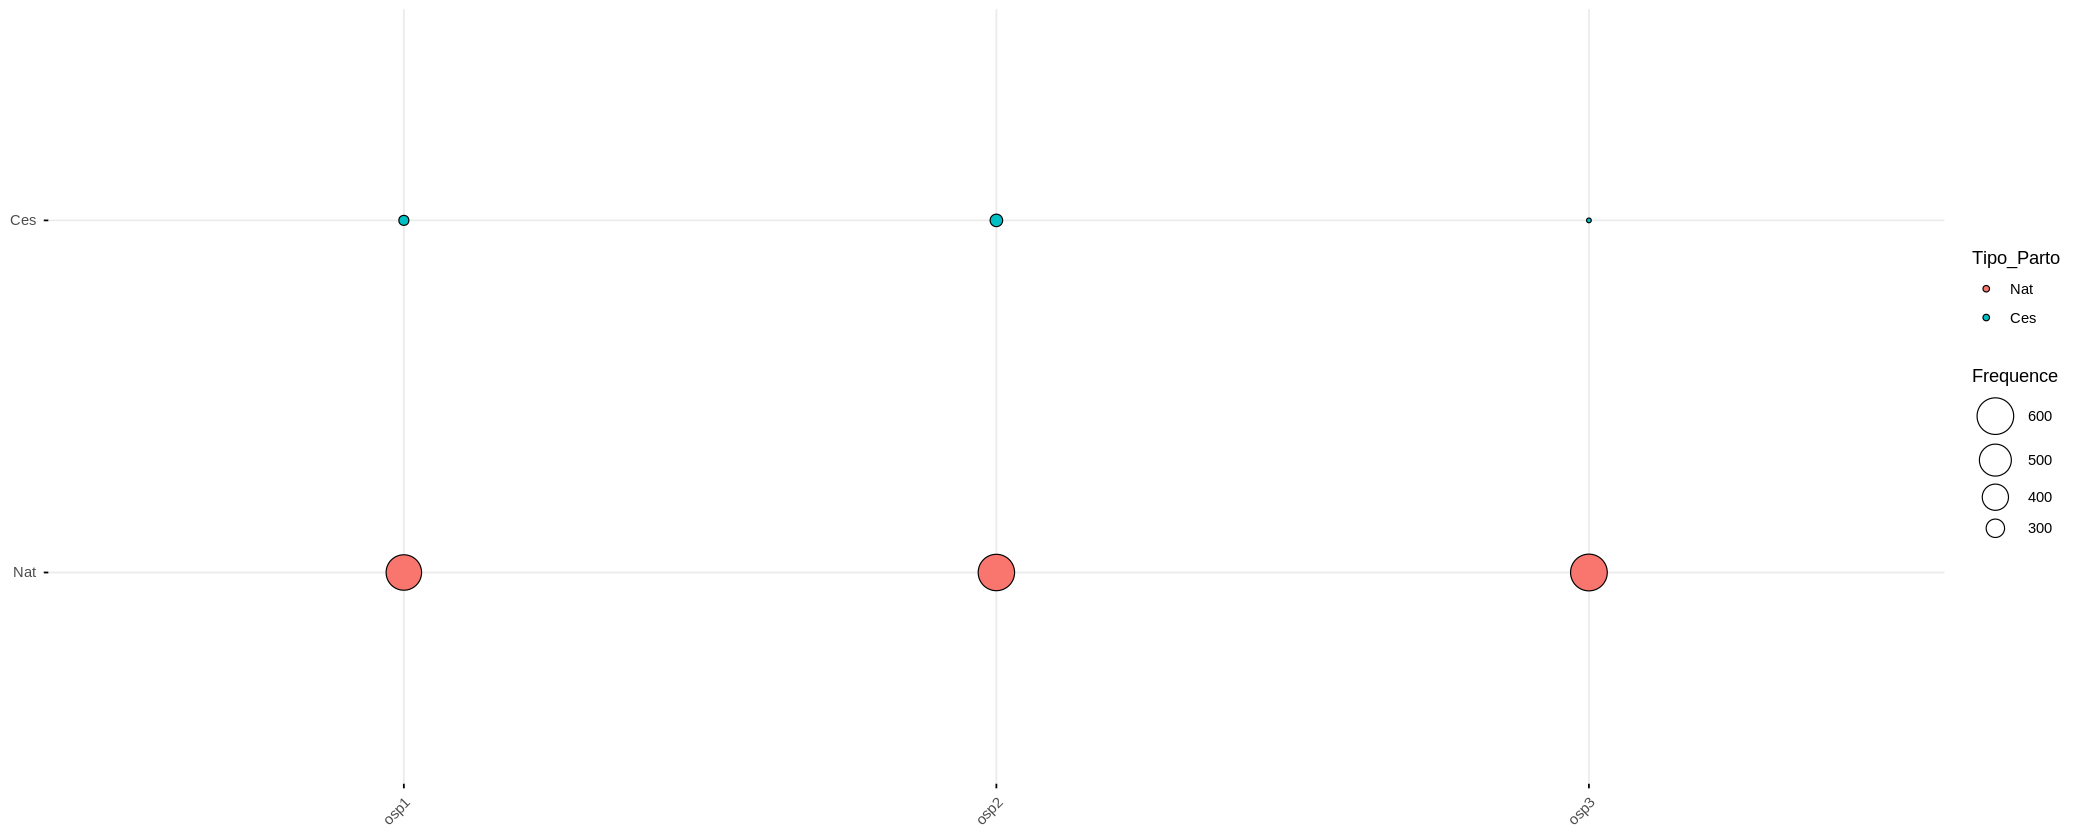

In [15]:
ggpubr::ggballoonplot(data=df.tipo_parto,
                      fill="Tipo_Parto")

The results show that Hospital 2 is the hospital where the highest number of cesarean deliveries is performed, while Hospital 3 is the hospital where the highest number of natural deliveries is performed.

We will now assess whether the difference in cesarean deliveries is statistically significant using a Chi-square test.

**H0 = delivery type is independent of hospital**  
**H1 = delivery type depends on hospital**

In [16]:
# HYPOTHESIS TEST - T-TEST

test = chisq.test(tabella.tipo_parto)

kable(data.frame(
  X2 = round(test$statistic,2),
  df = test$parameter,
  p_value = round(test$p.value,2)
),
caption = "Chi-square Test for Delivery Type")



Table: Chi-square Test for Delivery Type

|          |  X2| df| p_value|
|:---------|---:|--:|-------:|
|X-squared | 1.1|  2|    0.58|

The p-value of 0.58 shows that the differences in delivery type across hospitals are not statistically significant. These differences are therefore simply due to sampling variability, and consequently Hospital 2 does not appear to have any specific characteristic that would lead it to perform, on average, a higher number of cesarean deliveries than the other two hospitals.

### Hypothesis 2: The mean weight and length of this sample of newborns are significantly equal to those of the population

To test this hypothesis, I will use a t-test. For the population weight and length values, I used data obtained from the website of a well-known Italian pediatric hospital:  
https://www.ospedalebambinogesu.it/da-0-a-30-giorni-come-si-presenta-e-come-cresce-80012/

The value found for the population reference length is: **500 mm**

The hypothesis system for the “Lunghezza” variable is:

**H0: mu = 500**  
**H1: mu != 500**

In [31]:
# HYPOTHESIS TEST ("Lunghezza") - T-TEST

t.test_l = t.test(Lunghezza,
               mu = 500,
               conf.level = 0.95,
               alternative = "two.sided")

t_table_l = data.frame(
  t_statistic = round(t.test_l$statistic, 3),
  sample_mean = round(t.test_l$estimate, 2),
  expected_mean = 500,
  P_value = round(t.test_l$p.value, 4),
  IC_lower = round(t.test_l$conf.int[1], 2),
  IC_upper = round(t.test_l$conf.int[2], 2)
)

kable(t_table_l, caption = "T-test Results for 'Lunghezza'")



Table: T-test Results for 'Lunghezza'

|   | t_statistic| sample_mean| expected_mean| P_value| IC_lower| IC_upper|
|:--|-----------:|-----------:|-------------:|-------:|--------:|--------:|
|t  |     -10.084|      494.69|           500|       0|   493.66|   495.72|

The result shows that the sample mean length is significantly different from the population mean. In fact, the extremely small p-value and a confidence interval that does not contain the expected mean value lead us to reject the null hypothesis.

The hypothesis system for the “Peso” variable is:

**H0: mu = 3500**  
**H1: mu != 3500**

In [32]:
# HYPOTHESIS TEST ("Peso") - T-TEST

t.test_p = t.test(Peso,
       mu=3500,
       conf.level = 0.95,
       alternative = "two.sided")

t_table_p = data.frame(
  t_statistic = round(t.test_p$statistic, 3),
  sample_mean = round(t.test_p$estimate, 2),
  expected_mean = 3500,
  P_value = round(t.test_p$p.value, 4),
  IC_lower = round(t.test_p$conf.int[1], 2),
  IC_upper = round(t.test_p$conf.int[2], 2)
)

kable(t_table_p, caption = "T-test Results for 'Peso'")



Table: T-test Results for 'Peso'

|   | t_statistic| sample_mean| expected_mean| P_value| IC_lower| IC_upper|
|:--|-----------:|-----------:|-------------:|-------:|--------:|--------:|
|t  |     -20.562|     3284.08|          3500|       0|  3263.49|  3304.67|

In this case as well, the small p-value and the position of the confidence interval lead us to reject the null hypothesis and conclude that the sample mean weight is significantly different from the population mean.

### Hypothesis 3: Anthropometric measurements are significantly different between the two sexes

Boxplots are used to visually assess the differences, together with a summary of descriptive statistics.

#### 3.1 “Peso”-“Sesso” Check - “Peso” Conditioned on “Sesso”

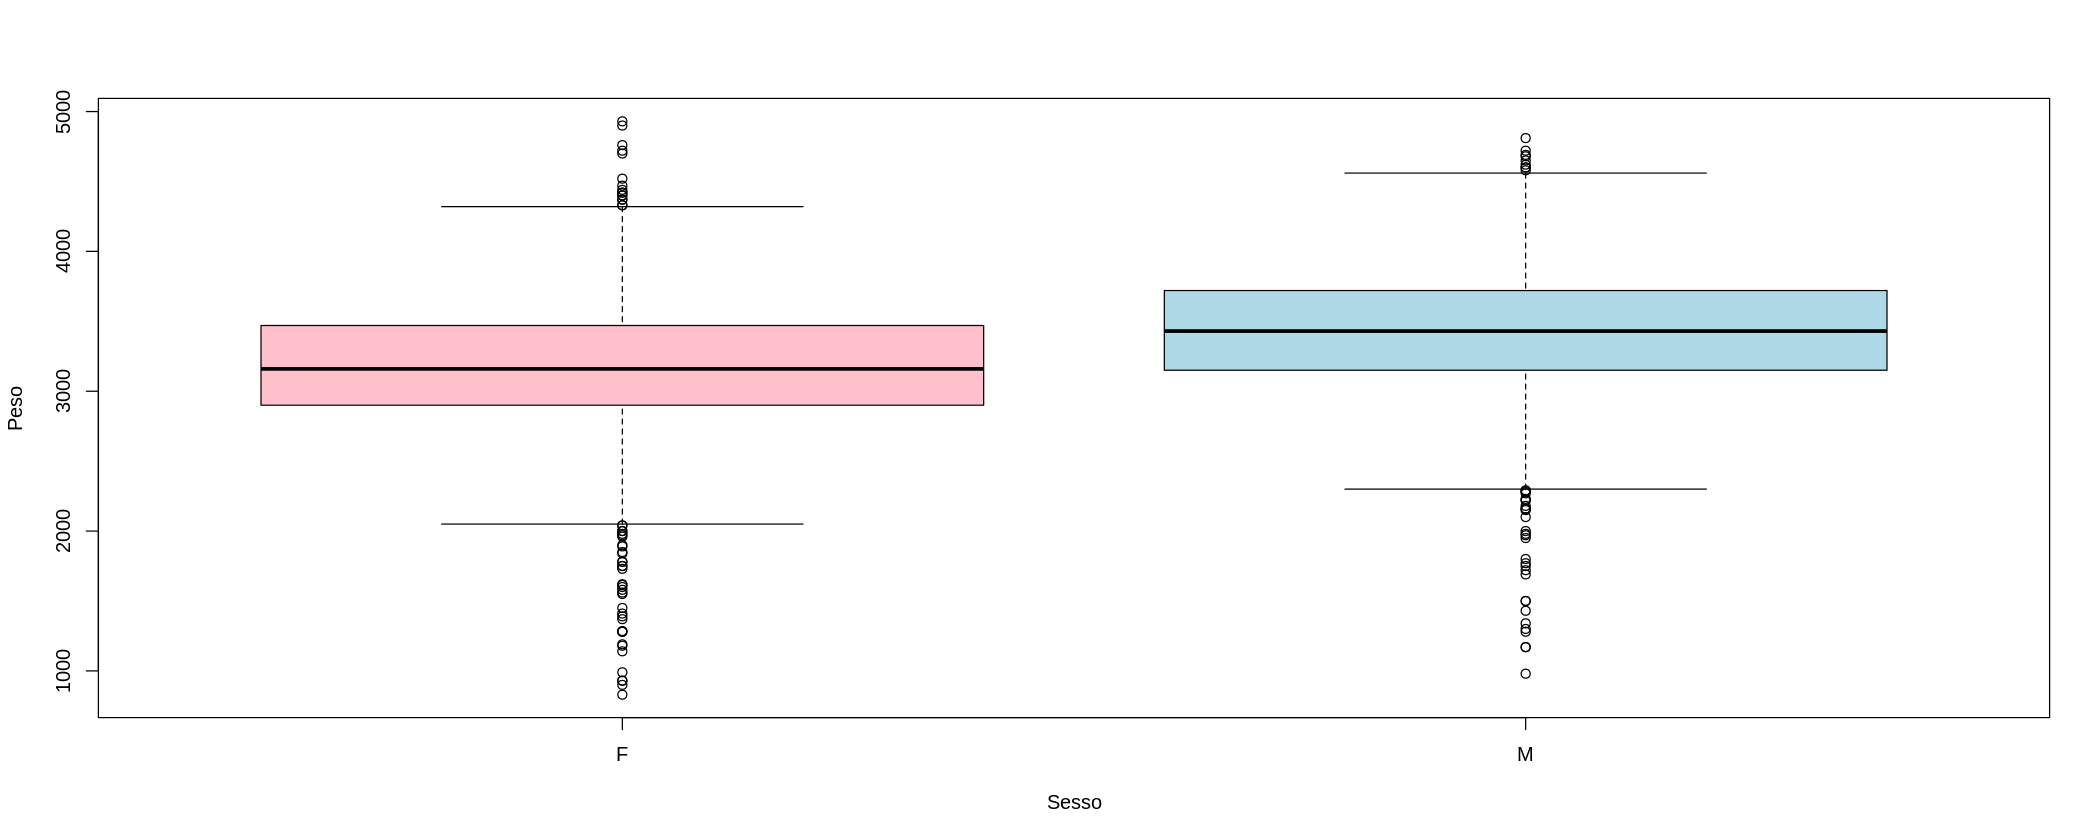

In [19]:
# BOXPLOT GENERATION

boxplot(Peso~Sesso,
        col=c("pink", "lightblue"))

In [33]:
# "Peso" SUMMARY - MALES

summary_p_m = summary(nb_data$Peso[nb_data$Sesso == "M"])

df_summary_p_m = as.data.frame(t(as.numeric(summary_p_m)))
colnames(df_summary_p_m)  = names(summary_p_m)

kable(df_summary_p_m,
      caption = "Descriptive Statistics for 'Peso' (Males)",
      digits = 0)



Table: Descriptive Statistics for 'Peso' (Males)

| Min.| 1st Qu.| Median| Mean| 3rd Qu.| Max.|
|----:|-------:|------:|----:|-------:|----:|
|  980|    3150|   3430| 3408|    3720| 4810|

In [34]:
# "Peso" SUMMARY - FEMALES

summary_p_f = summary(nb_data$Peso[nb_data$Sesso == "F"])

df_summary_p_f = as.data.frame(t(as.numeric(summary_p_f)))
colnames(df_summary_p_f)  = names(summary_p_f)

kable(df_summary_p_f,
      caption = "Descriptive Statistics for 'Peso' (Females)",
      digits = 0)



Table: Descriptive Statistics for 'Peso' (Females)

| Min.| 1st Qu.| Median| Mean| 3rd Qu.| Max.|
|----:|-------:|------:|----:|-------:|----:|
|  830|    2900|   3160| 3161|    3470| 4930|

#### 3.2 “Lunghezza”-“Sesso” Check - “Lunghezza” Conditioned on “Sesso”

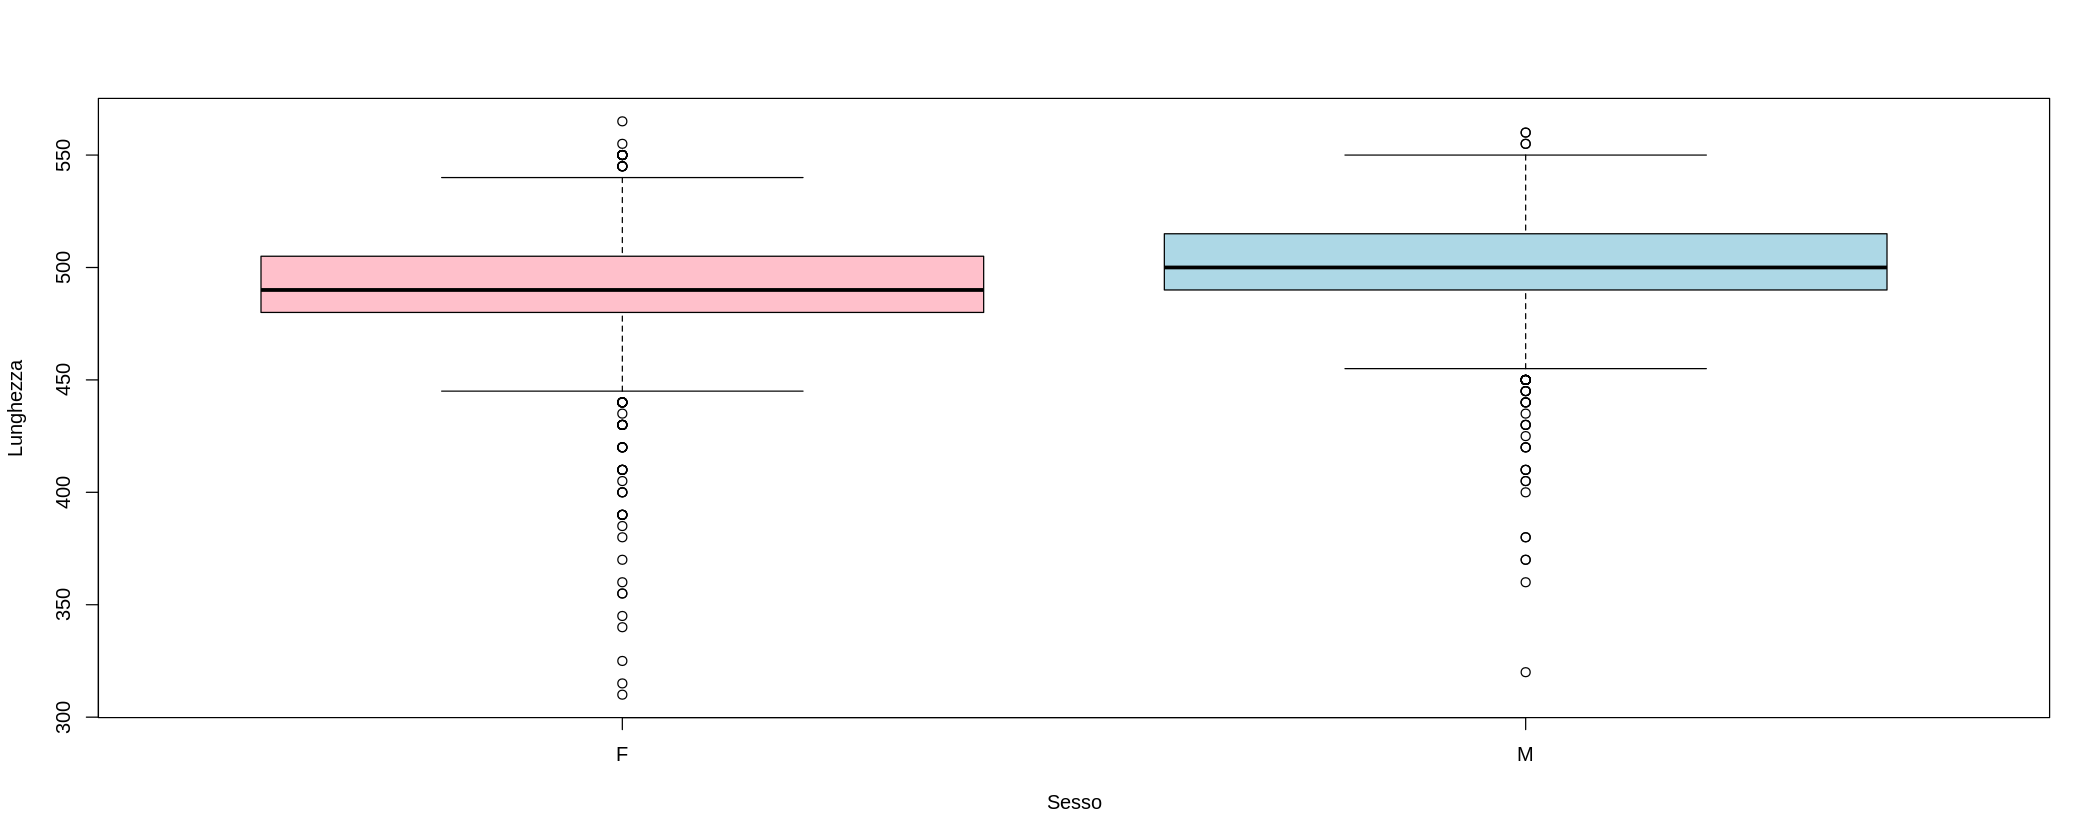

In [22]:
# BOXPLOT GENERATION

boxplot(Lunghezza~Sesso,
        col=c("pink", "lightblue"))

In [35]:
# "Lunghezza" SUMMARY - MALES

summary_l_m = summary(nb_data$Lunghezza[nb_data$Sesso == "M"])

df_summary_l_m = as.data.frame(t(as.numeric(summary_l_m)))
colnames(df_summary_l_m)  = names(summary_l_m)

kable(df_summary_l_m,
      caption = "Descriptive Statistics for 'Lunghezza' (Males)",
      digits = 0)



Table: Descriptive Statistics for 'Lunghezza' (Males)

| Min.| 1st Qu.| Median| Mean| 3rd Qu.| Max.|
|----:|-------:|------:|----:|-------:|----:|
|  320|     490|    500|  500|     515|  560|

In [36]:
# "Lunghezza" SUMMARY - FEMALES

summary_l_f = summary(nb_data$Lunghezza[nb_data$Sesso == "F"])

df_summary_l_f = as.data.frame(t(as.numeric(summary_l_f)))
colnames(df_summary_l_f)  = names(summary_l_f)

kable(df_summary_l_f,
      caption = "Descriptive Statistics for 'Lunghezza' (Females)",
      digits = 0)



Table: Descriptive Statistics for 'Lunghezza' (Females)

| Min.| 1st Qu.| Median| Mean| 3rd Qu.| Max.|
|----:|-------:|------:|----:|-------:|----:|
|  310|     480|    490|  490|     505|  565|

#### 3.3 “Cranio”-“Sesso” Check - “Cranio” Conditioned on “Sesso”

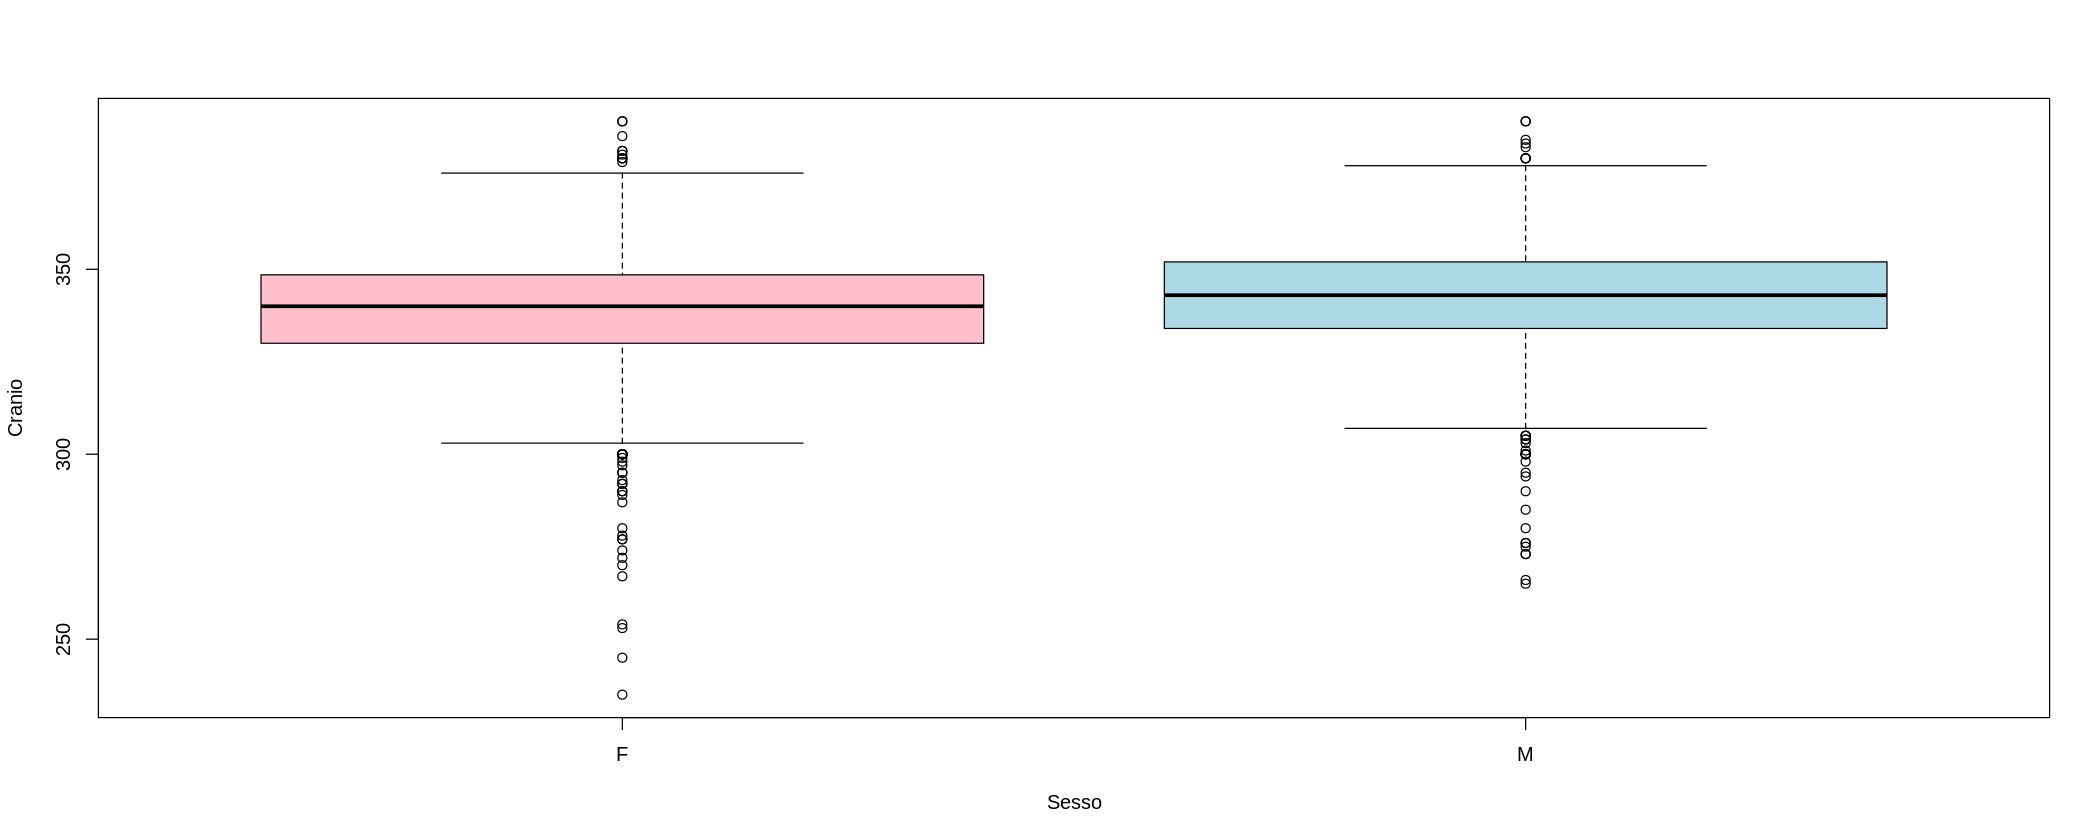

In [25]:
# BOXPLOT GENERATION

boxplot(Cranio~Sesso,
        col=c("pink", "lightblue"))

In [37]:
# "Cranio" SUMMARY - MALES

summary_c_m = summary(nb_data$Cranio[nb_data$Sesso == "M"])

df_summary_c_m = as.data.frame(t(as.numeric(summary_c_m)))
colnames(df_summary_c_m)  = names(summary_c_m)

kable(df_summary_c_m,
      caption = "Descriptive Statistics for 'Cranio' (Males)",
      digits = 0)



Table: Descriptive Statistics for 'Cranio' (Males)

| Min.| 1st Qu.| Median| Mean| 3rd Qu.| Max.|
|----:|-------:|------:|----:|-------:|----:|
|  265|     334|    343|  342|     352|  390|

In [38]:
# "Cranio" SUMMARY - FEMALES

summary_c_f = summary(nb_data$Cranio[nb_data$Sesso == "F"])

df_summary_c_f = as.data.frame(t(as.numeric(summary_c_f)))
colnames(df_summary_c_f)  = names(summary_c_f)

kable(df_summary_c_f,
      caption = "Descriptive Statistics for 'Cranio' (Females)",
      digits = 0)



Table: Descriptive Statistics for 'Cranio' (Females)

| Min.| 1st Qu.| Median| Mean| 3rd Qu.| Max.|
|----:|-------:|------:|----:|-------:|----:|
|  235|     330|    340|  338|     348|  390|

For all anthropometric measurements, males show higher values; the difference is more evident for weight (mean of 3408 g versus 3161 g) and less pronounced for length (mean of 500 mm versus 490 mm) and cranial diameter (mean of 342 mm versus 338 mm).

We will now test whether the differences visible in the boxplots and reflected in the reported means are statistically significant.

For all three anthropometric measurements, H0 states that the difference in means between the two sexes is 0. We will use a t-test to test this hypothesis.

#### 3.1 T-test for “Peso”

In [42]:
# HYPOTHESIS TEST ("Peso") - T-TEST

t.test_p_s = t.test(data=nb_data,
                Peso~Sesso)

t.tab_p_s = data.frame(
  t_statistic = round(t.test_p_s$statistic, 3),
  degrees_of_freedom = round(t.test_p_s$parameter, 1),
  p.value = round(t.test_p_s$p.value,3),
  IC_upper = round(t.test_p_s$conf.int[1], 2),
  IC_lower = round(t.test_p_s$conf.int[2], 2),
  mean_F = round(t.test_p_s$estimate[1], 3),
  Mean_M = round(t.test_p_s$estimate[2], 3)
)

kable(t.tab_p_s, caption = "T-test results for 'Peso' between males and females")



Table: T-test Results for 'Peso' between males and females

|   | t_statistic| degrees_of_freedom| p.value| IC_upper| IC_lower|   mean_F|   Mean_M|
|:--|-----------:|------------------:|-------:|--------:|--------:|--------:|--------:|
|t  |     -12.106|             2490.7|       0|  -287.11|  -207.06| 3161.132| 3408.215|

Both the p-value, which is below the significance level, and a confidence interval that does not contain the value 0 specified under H0 lead us to reject the null hypothesis.

#### 3.2 T-test for “Lunghezza”

In [44]:
# HYPOTHESIS TEST ("Peso") - T-TEST

t.test_l_s = t.test(data=nb_data,
                Lunghezza~Sesso)

t.tab_l_s = data.frame(
  t_statistic = round(t.test_l_s$statistic, 3),
  degrees_of_freedom = round(t.test_l_s$parameter, 1),
  p.value = round(t.test_l_s$p.value,3),
  IC_upper = round(t.test_l_s$conf.int[1], 2),
  IC_lower = round(t.test_l_s$conf.int[2], 2),
  mean_F = round(t.test_l_s$estimate[1], 3),
  Mean_M = round(t.test_l_s$estimate[2], 3)
)

kable(t.tab_l_s, caption = "T-test results for 'Lunghezza' between males and females")



Table: T-test results for 'Lunghezza' between males and females

|   | t_statistic| degrees_of_freedom| p.value| IC_upper| IC_lower|  mean_F|  Mean_M|
|:--|-----------:|------------------:|-------:|--------:|--------:|-------:|-------:|
|t  |      -9.582|             2459.3|       0|   -11.93|    -7.88| 489.764| 499.667|

In this case as well, both the p-value and the position of the confidence interval lead us to reject the null hypothesis.

#### T-test for the “Cranio”

#### 3.3 T-test for “Cranio” Variable

In [45]:
# HYPOTHESIS TEST ("Cranio") - T-TEST

t.test_c_s = t.test(data=nb_data,
                Cranio~Sesso)

t.tab_c_s = data.frame(
  t_statistic = round(t.test_c_s$statistic, 3),
  degrees_of_freedom = round(t.test_c_s$parameter, 1),
  p.value = round(t.test_c_s$p.value,3),
  IC_upper = round(t.test_c_s$conf.int[1], 2),
  IC_lower = round(t.test_c_s$conf.int[2], 2),
  mean_F = round(t.test_c_s$estimate[1], 3),
  Mean_M = round(t.test_c_s$estimate[2], 3)
)

kable(t.tab_c_s, caption = "T-test results for 'Cranio' between males and females")



Table: T-test results for 'Cranio' between males and females

|   | t_statistic| degrees_of_freedom| p.value| IC_upper| IC_lower|  mean_F|  Mean_M|
|:--|-----------:|------------------:|-------:|--------:|--------:|-------:|-------:|
|t  |       -7.41|             2491.4|       0|    -6.09|    -3.54| 337.633| 342.449|

The result of this test is the same as for the previous two tests: H0 is rejected because the p-value is well below 0.05 and the confidence interval does not contain 0.

Overall, both the p-values and the confidence intervals obtained from the tests on the anthropometric measurements lead us to reject H0. The differences between the sexes are therefore statistically significant.

# 2. Regression model development

A multiple linear regression model including all relevant variables will be developed. This will allow us to quantify the impact of each independent variable on newborn weight and any interaction effects.

## 2.1 Preliminary checks

I assess the normality of the response variable “Peso” using the Shapiro test.

In [46]:
# NORMALITY TEST FOR "Peso" - SHAPIRO TEST

shap.test.p = shapiro.test(Peso)

p_value = round(shap.test.p$p.value,3)

kable(data.frame("p-value" = p_value),
      caption = "Shapiro Test Result")



Table: Shapiro Test Result

| p.value|
|-------:|
|       0|

The p-value leads us to reject the null hypothesis of normality for “Peso”.

We now visually assess the relationships among variables.

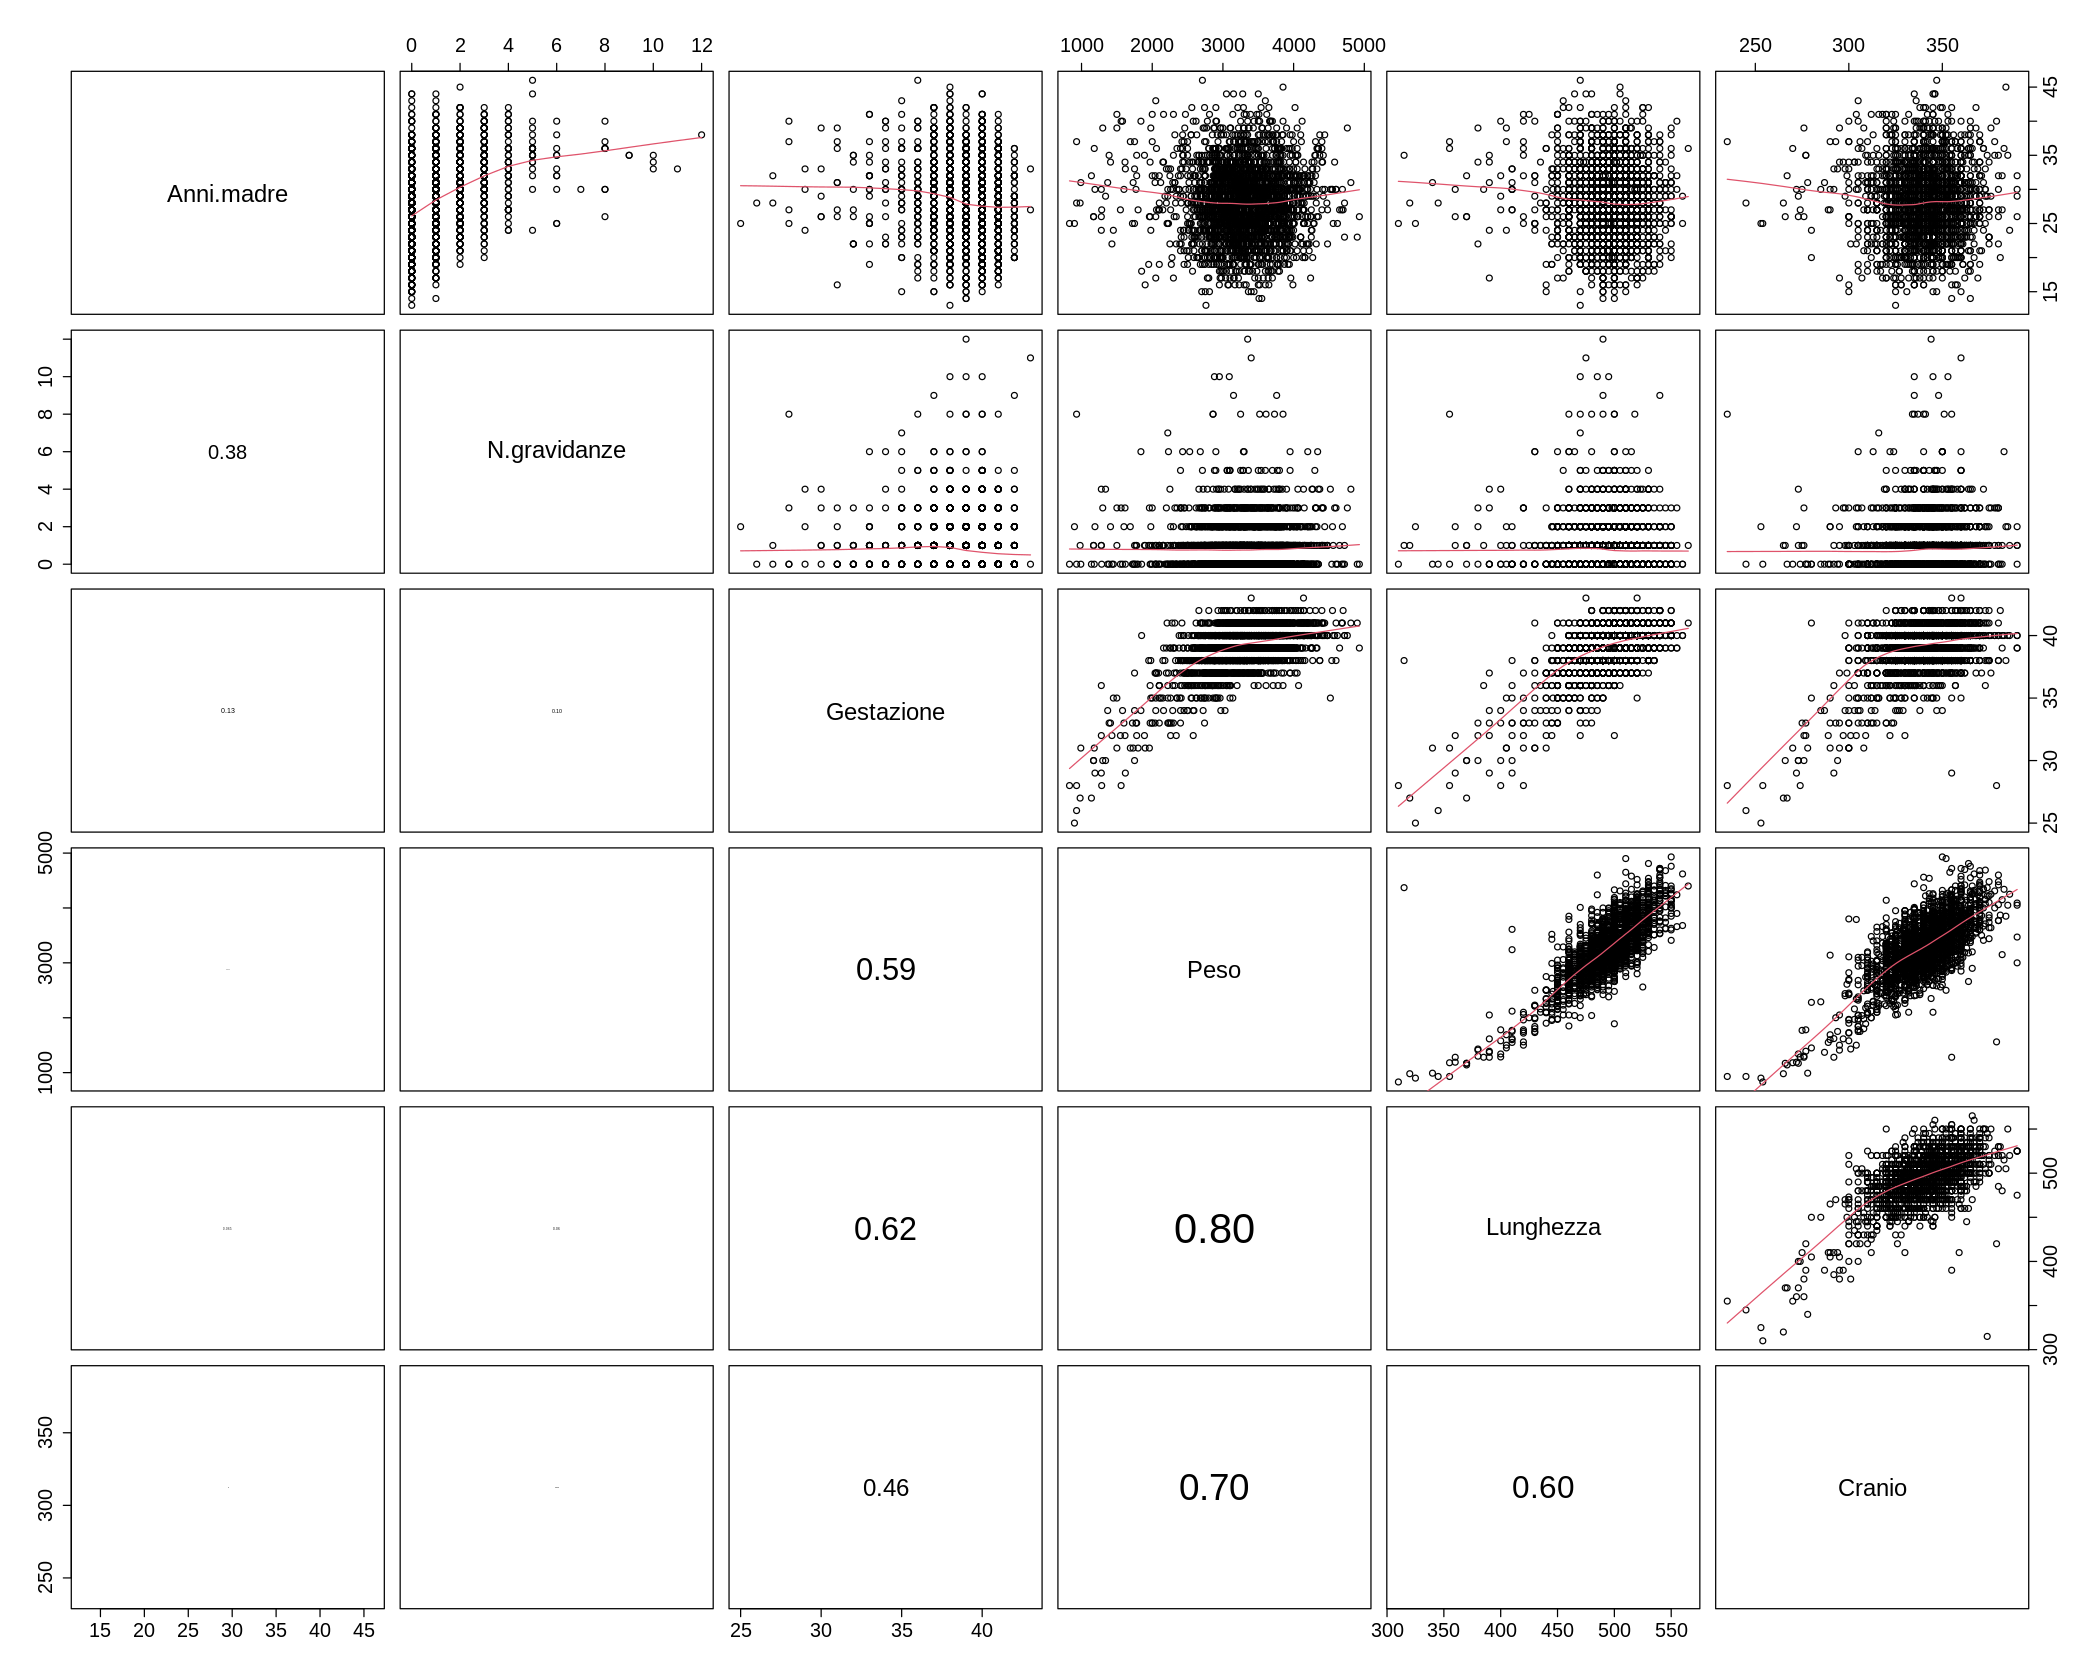

In [47]:
# PLOT GENERATION

options(
  repr.plot.width = 17.5,
  repr.plot.height = 14
)

panel.cor = function(x, y, digits = 2, prefix = "", cex.cor, ...)
{
  usr = par("usr")
  on.exit(par(usr = usr))

  par(usr = c(0, 1, 0, 1))

  r = abs(cor(x, y))

  txt = format(c(r, 0.123456789), digits = digits)[1]
  txt = paste0(prefix, txt)

  if (missing(cex.cor)) {
    cex.cor = 1.3 / strwidth(txt)
  }

  text(0.5, 0.5, txt, cex = cex.cor * r)
}

par(cex.axis = 1.5)

pairs(
  nb_data[, !(names(nb_data) %in%
                c("Sesso", "Ospedale", "Tipo.parto", "Fumatrici"))],
  upper.panel = panel.smooth,
  lower.panel = panel.cor,
  cex.labels = 1.8
)

The strongest correlations are between "Peso" (weight) and "Lunghezza", with a value of 0.8, and between "Peso" and "Cranio" (0.7). Correlations above 0.5 are also observed between:

- "Gestazione" and "Peso" (0.59);
- "Gestazione" and "Lunghezza" (0.62);
- "Lunghezza" and "Cranio" (0.60).

Graphically, the relationship between "Peso" and "Lunghezza" appears to be perfectly linear, as does the relationship between "Peso" and "Cranio", whereas the "Gestazione"-"Peso", "Gestazione"-"Lunghezza", "Gestazione" and "Cranio", and "Lunghezza"-"Cranio" relationships do not appear to be simple linear relationships and seem to display a quadratic pattern.

## 2.2 Model development

For the initial model, we will exclude “Ospedale” and “Tipo.parto”, since they are intuitively expected not to have meaningful predictive power.

### Model 1 - All variables

In [48]:
# MODEL 1: ESTIMATION WITH ALL VARIABLES

model1 = lm(Peso ~ Anni.madre + N.gravidanze + Fumatrici + Gestazione + Lunghezza + Cranio + Sesso,
data = nb_data)

summary(model1)


Call:
lm(formula = Peso ~ Anni.madre + N.gravidanze + Fumatrici + Gestazione + 
    Lunghezza + Cranio + Sesso, data = nb_data)

Residuals:
     Min       1Q   Median       3Q      Max 
-1160.61  -181.18   -15.91   163.47  2631.35 

Coefficients:
               Estimate Std. Error t value Pr(>|t|)    
(Intercept)  -6711.5188   141.2541 -47.514  < 2e-16 ***
Anni.madre       0.8764     1.1487   0.763   0.4455    
N.gravidanze    11.4040     4.6745   2.440   0.0148 *  
Fumatrici      -30.2864    27.5981  -1.097   0.2726    
Gestazione      32.8932     3.8259   8.598  < 2e-16 ***
Lunghezza       10.2348     0.3009  34.010  < 2e-16 ***
Cranio          10.5192     0.4268  24.644  < 2e-16 ***
SessoM          78.0898    11.2042   6.970 4.05e-12 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 274.6 on 2492 degrees of freedom
Multiple R-squared:  0.7272,	Adjusted R-squared:  0.7264 
F-statistic:   949 on 7 and 2492 DF,  p-value: < 2.2e-16


In this initial model, the most significant variables are: “Gestazione”, “Lunghezza”, “Cranio”, and “Sesso”. “Anni.madre” and “Fumatrici” are not statistically significant, while “N.gravidanze” is statistically significant at the 5% level.

Holding the other variables constant, the estimated coefficients indicate a positive association with mean newborn weight for all the variables considered, except “Fumatrici”, which has a negative coefficient. However, the magnitude of the coefficients cannot be used directly to compare the importance of the variables, since they are expressed in different units of measurement.

To select the final model, we will first exclude non-significant variables and then evaluate possible quadratic patterns in some variables and interaction effects among them.

The adjusted R² of this model is a good value, approximately 73% (0.7264), meaning that more than 70% of the variability in Y is explained by the variables included in the model.

### Model 2 - Removing “Anni.madre” and “Fumatrici”

In [49]:
# MODEL 2: EXCLUDING "Anni.madre" AND "Fumatrici"

model2 = update(model1,~.-Anni.madre - Fumatrici)

summary(model2)


Call:
lm(formula = Peso ~ N.gravidanze + Gestazione + Lunghezza + Cranio + 
    Sesso, data = nb_data)

Residuals:
     Min       1Q   Median       3Q      Max 
-1149.44  -180.81   -15.58   163.64  2639.72 

Coefficients:
               Estimate Std. Error t value Pr(>|t|)    
(Intercept)  -6681.1445   135.7229 -49.226  < 2e-16 ***
N.gravidanze    12.4750     4.3396   2.875  0.00408 ** 
Gestazione      32.3321     3.7980   8.513  < 2e-16 ***
Lunghezza       10.2486     0.3006  34.090  < 2e-16 ***
Cranio          10.5402     0.4262  24.728  < 2e-16 ***
SessoM          77.9927    11.2021   6.962 4.26e-12 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 274.6 on 2494 degrees of freedom
Multiple R-squared:  0.727,	Adjusted R-squared:  0.7265 
F-statistic:  1328 on 5 and 2494 DF,  p-value: < 2.2e-16


The explanatory power of the model remains unchanged, as shown by the adjusted R², which is predictably almost identical (from 0.7264 to 0.7265) given the lack of significance of the removed variables. In addition, the coefficients changed only minimally compared with the previous model.

We will now investigate quadratic effects.

### Investigation of Quadratic Effects for “Gestazione”

### Model 3 = Model 2 + “Gestazione”²

Since the graphical analysis of the variables suggested a relationship between “Gestazione” and the response variable that is not purely linear, the squared form of this explanatory variable is added to the model while retaining its first-order term.

In [50]:
# MODEL 3: MODEL 2 + Gestazione²

model3.g_g2 = update(model2,.~.+I(Gestazione^2))

summary(model3.g_g2)


Call:
lm(formula = Peso ~ N.gravidanze + Gestazione + Lunghezza + Cranio + 
    Sesso + I(Gestazione^2), data = nb_data)

Residuals:
     Min       1Q   Median       3Q      Max 
-1144.11  -181.17   -13.16   165.73  2662.56 

Coefficients:
                  Estimate Std. Error t value Pr(>|t|)    
(Intercept)     -4650.2268   898.1706  -5.177 2.43e-07 ***
N.gravidanze       12.5660     4.3361   2.898  0.00379 ** 
Gestazione        -81.0486    49.7127  -1.630  0.10316    
Lunghezza          10.3534     0.3039  34.074  < 2e-16 ***
Cranio             10.6363     0.4280  24.854  < 2e-16 ***
SessoM             75.7900    11.2340   6.747 1.88e-11 ***
I(Gestazione^2)     1.5136     0.6617   2.287  0.02226 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 274.4 on 2493 degrees of freedom
Multiple R-squared:  0.7276,	Adjusted R-squared:  0.7269 
F-statistic:  1110 on 6 and 2493 DF,  p-value: < 2.2e-16


The new model shows a negligible increase in explanatory power (from 0.7265 to 0.7269). The inclusion of the quadratic term for Gestazione causes the linear coefficient to lose significance and change sign, while the quadratic term is significant at the 5% level. This suggests a possible collinearity problem between the two components (linear and quadratic). In light of this, the “Gestazione” variable will be centered (in accordance with the principle of marginality), after which the quadratic term will be constructed from the centered variable while retaining both components in the model.

### Model 4 - Centered “Gestazione”

In [64]:
# MODEL 4: CENTERED "Gestazione" AND "Gestazione"²

nb_data$Gestazione_c =
  nb_data$Gestazione - mean(nb_data$Gestazione)

model4.gc_gc2 = lm(
  Peso ~ N.gravidanze +
    Gestazione_c +
    I(Gestazione_c^2) +
    Lunghezza +
    Cranio +
    Sesso,
  data = nb_data
)
summary(model4.gc_gc2)


Call:
lm(formula = Peso ~ N.gravidanze + Gestazione_c + I(Gestazione_c^2) + 
    Lunghezza + Cranio + Sesso, data = nb_data)

Residuals:
     Min       1Q   Median       3Q      Max 
-1144.11  -181.17   -13.16   165.73  2662.56 

Coefficients:
                    Estimate Std. Error t value Pr(>|t|)    
(Intercept)       -5509.6403   157.7961 -34.916  < 2e-16 ***
N.gravidanze         12.5660     4.3361   2.898  0.00379 ** 
Gestazione_c         36.9540     4.2992   8.596  < 2e-16 ***
I(Gestazione_c^2)     1.5136     0.6617   2.287  0.02226 *  
Lunghezza            10.3534     0.3039  34.074  < 2e-16 ***
Cranio               10.6363     0.4280  24.854  < 2e-16 ***
SessoM               75.7900    11.2340   6.747 1.88e-11 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 274.4 on 2493 degrees of freedom
Multiple R-squared:  0.7276,	Adjusted R-squared:  0.7269 
F-statistic:  1110 on 6 and 2493 DF,  p-value: < 2.2e-16


Centering "Gestazione" does not change the explanatory power of the model, which retains an adjusted R² of 0.7269, slightly higher than that of the linear model (model2, 0.7265).

However, the new parameterization makes the linear "Gestazione" term significant. This result does not arise from an improvement in the model's predictive performance, but from the different meaning assumed by the linear coefficient: after centering, it represents the behavior of the relationship at the mean gestation value rather than at Gestazione = 0. The quadratic term remains significant at the 5% level.

### Development of Models with Interaction Terms

### Model 5 - “Gestazione”-“Lunghezza” interaction

In [52]:
# MODEL 5: "Gestazione" - "Lunghezza" INTERACTION

model5.int.g_l = lm(Peso ~ Gestazione*Lunghezza+N.gravidanze+Cranio+Sesso)
summary(model5.int.g_l)


Call:
lm(formula = Peso ~ Gestazione * Lunghezza + N.gravidanze + Cranio + 
    Sesso)

Residuals:
     Min       1Q   Median       3Q      Max 
-1133.50  -179.45   -11.74   168.77  2653.34 

Coefficients:
                       Estimate Std. Error t value Pr(>|t|)    
(Intercept)          -1.991e+03  9.202e+02  -2.163 0.030619 *  
Gestazione           -9.396e+01  2.480e+01  -3.789 0.000155 ***
Lunghezza            -8.111e-02  2.027e+00  -0.040 0.968082    
N.gravidanze          1.304e+01  4.319e+00   3.020 0.002551 ** 
Cranio                1.076e+01  4.262e-01  25.245  < 2e-16 ***
SessoM                7.228e+01  1.120e+01   6.454 1.31e-10 ***
Gestazione:Lunghezza  2.729e-01  5.295e-02   5.153 2.76e-07 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 273.2 on 2493 degrees of freedom
Multiple R-squared:  0.7299,	Adjusted R-squared:  0.7292 
F-statistic:  1123 on 6 and 2493 DF,  p-value: < 2.2e-16


The inclusion of the interaction term increases the adjusted R², although only slightly, from 0.7265 to 0.7292. The coefficient associated with the main effect of “Lunghezza” loses statistical significance, while the interaction term is significant.

### Model 6 - “Gestazione”-“Cranio” interaction

In [53]:
# MODEL 6: "Gestazione" - "Cranio" INTERACTION

model6.int.g_c = lm(Peso ~ Gestazione*Cranio+N.gravidanze+Lunghezza+Sesso)
summary(model6.int.g_c)


Call:
lm(formula = Peso ~ Gestazione * Cranio + N.gravidanze + Lunghezza + 
    Sesso)

Residuals:
     Min       1Q   Median       3Q      Max 
-1137.16  -180.86   -12.44   167.43  2696.03 

Coefficients:
                    Estimate Std. Error t value Pr(>|t|)    
(Intercept)       -193.11866 1106.42819  -0.175  0.86145    
Gestazione        -140.67784   29.52621  -4.765 2.00e-06 ***
Cranio              -9.83681    3.47497  -2.831  0.00468 ** 
N.gravidanze        13.14181    4.31191   3.048  0.00233 ** 
Lunghezza           10.47042    0.30096  34.790  < 2e-16 ***
SessoM              72.05680   11.17200   6.450 1.34e-10 ***
Gestazione:Cranio    0.53339    0.09028   5.908 3.94e-09 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 272.8 on 2493 degrees of freedom
Multiple R-squared:  0.7308,	Adjusted R-squared:  0.7301 
F-statistic:  1128 on 6 and 2493 DF,  p-value: < 2.2e-16


The "Gestazione"-"Cranio" interaction produces the model with the highest adjusted R² so far (0.7301). Unlike what was observed for “Lunghezza” in the previous model, the coefficient associated with the main effect of “Cranio” remains statistically significant; the “Gestazione”-“Cranio” interaction term is also significant.

### Model 7 - “Lunghezza”-“Cranio” interaction

In [56]:
# MODEL 7: "Lunghezza" - "Cranio" INTERACTION

model7.int.l_c = lm(Peso ~ Lunghezza*Cranio+N.gravidanze+Gestazione+Sesso)
summary(model7.int.l_c)


Call:
lm(formula = Peso ~ Lunghezza * Cranio + N.gravidanze + Gestazione + 
    Sesso)

Residuals:
     Min       1Q   Median       3Q      Max 
-1150.74  -180.48   -13.62   165.82  2866.17 

Coefficients:
                   Estimate Std. Error t value Pr(>|t|)    
(Intercept)      -1.801e+03  1.018e+03  -1.770  0.07685 .  
Lunghezza        -3.047e-01  2.202e+00  -0.138  0.88996    
Cranio           -4.759e+00  3.191e+00  -1.491  0.13601    
N.gravidanze      1.295e+01  4.321e+00   2.996  0.00276 ** 
Gestazione        3.810e+01  3.964e+00   9.610  < 2e-16 ***
SessoM            7.327e+01  1.119e+01   6.545 7.20e-11 ***
Lunghezza:Cranio  3.158e-02  6.528e-03   4.838 1.39e-06 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 273.4 on 2493 degrees of freedom
Multiple R-squared:  0.7295,	Adjusted R-squared:  0.7289 
F-statistic:  1121 on 6 and 2493 DF,  p-value: < 2.2e-16


This interaction produces a decrease in adjusted R² compared with the previous model, bringing it to 0.7289. In addition, the coefficients associated with the main effects of “Lunghezza” and “Cranio” are not statistically significant, while the “Lunghezza”-“Cranio” interaction term is highly significant.

## 2.3 Optimal Model Selection

Using model-selection techniques such as minimizing the Akaike Information Criterion (AIC) or Bayesian Information Criterion (BIC), we will select the most parsimonious model by removing non-significant variables. Models with interactions and possible nonlinear effects will also be considered.

### BIC

In [66]:
# Function to calculate BIC

bic_table = function(models) {

  results = data.frame(
    df = sapply(models, function(model) attr(logLik(model), "df")),
    BIC = round(sapply(models, BIC), 0)
  )

  return(results)
}

In [67]:
models = list(
  model1 = model1,
  model2 = model2,
  model3.g_g2 = model3.g_g2,
  model4.gc_gc2 =model4.gc_g2,
  model5.int.g_l = model5.int.g_l,
  model6.int.g_c = model6.int.g_c,
  model7.int.l_c = model7.int.l_c
)

In [68]:
kable(bic_table(models))



|               | df|   BIC|
|:--------------|--:|-----:|
|model1         |  9| 35234|
|model2         |  7| 35220|
|model3.g_g2    |  8| 35223|
|model4.gc_gc2  |  8| 35223|
|model5.int.g_l |  8| 35201|
|model6.int.g_c |  8| 35193|
|model7.int.l_c |  8| 35205|

Overall, the model with the lowest BIC is model 6, which includes the interaction between “Gestazione” and “Cranio”.

Among the purely linear models, the model with the lowest BIC is the one containing only the most significant variables (model 2).

Among the models that include a quadratic component, model 4, which contains only the squared “Gestazione” variable, has the lowest BIC.

### VIF

In [69]:
# FUNCTION TO CALCULATE VIF VALUES

vif_models = function(models) {

  results = lapply(models, function(model) {

    # Check for interaction terms
    has_interaction = any(
      grepl(":", attr(terms(model), "term.labels"))
    )

    # Calculate VIF
    if (has_interaction) {
      vif_result = car::vif(model, type = "predictor")
    } else {
      vif_result = car::vif(model)
    }

    return(vif_result)
  })

  return(results)
}



In [70]:
# CALCULATE VIF VALUES FOR ALL MODELS

vif_results = vif_models(models)

GVIFs computed for predictors

GVIFs computed for predictors

GVIFs computed for predictors



In [71]:
# DISPLAY RESULTS

for (model_name in names(vif_results)) {

  cat("\n", model_name, "\n")

  print(
    kable(
      vif_results[[model_name]],
      digits = 2
    )
  )
}


 model1 


|             |    x|
|:------------|----:|
|Anni.madre   | 1.19|
|N.gravidanze | 1.19|
|Fumatrici    | 1.01|
|Gestazione   | 1.69|
|Lunghezza    | 2.08|
|Cranio       | 1.63|
|Sesso        | 1.04|

 model2 


|             |    x|
|:------------|----:|
|N.gravidanze | 1.02|
|Gestazione   | 1.67|
|Lunghezza    | 2.07|
|Cranio       | 1.62|
|Sesso        | 1.04|

 model3.g_g2 


|                |      x|
|:---------------|------:|
|N.gravidanze    |   1.02|
|Gestazione      | 286.47|
|Lunghezza       |   2.12|
|Cranio          |   1.64|
|Sesso           |   1.05|
|I(Gestazione^2) | 279.77|

 model4.gc_gc2 


|                  |    x|
|:-----------------|----:|
|N.gravidanze      | 1.02|
|Gestazione_c      | 2.14|
|I(Gestazione_c^2) | 1.82|
|Lunghezza         | 2.12|
|Cranio            | 1.64|
|Sesso             | 1.05|

 model5.int.g_l 


|             | GVIF| Df| GVIF^(1/(2*Df))|Interacts With |Other Predictors                            |
|:------------|----:|--:|-------

The VIF values are below 5 in the linear models (model1 and model2) and in the model containing centered "Gestazione" (g_c) and centered "Gestazione"² (gc2) (model4).

By contrast, model3, which simultaneously includes "Gestazione" (not centered) and "Gestazione"², shows very high VIF values for both components, indicating strong multicollinearity between the linear and quadratic terms.

In the interaction models (model5, model6, and model7), the GVIF values adjusted for degrees of freedom are close to 1 and do not indicate relevant multicollinearity issues.

## 2.4 Model choice

The selected model is model 2, “model2”, with the variables: “N.gravidanze”, “Gestazione”, “Lunghezza”, “Cranio”, and “Sesso”.

This version is selected because, despite being the simplest and containing neither quadratic terms nor interactions, its explanatory power is not substantially lower than that of more complex models.

"model2" is therefore considered the best compromise between predictive power and complexity, including interpretative complexity.

# 3. Model quality analysis
Once the final model has been obtained, we will evaluate its predictive performance using metrics such as R² and Root Mean Squared Error (RMSE). Particular attention will be paid to residual analysis and the presence of influential observations that could distort predictions.

## 3.1 Adjusted R² Analysis

For multiple linear regression models, it is preferable to consider adjusted R² because it does not increase simply as a result of adding regressors and may even decrease when an added regressor has little explanatory power or is added to an already substantial set of regressors.

In [72]:
tabella = matrix(data = c(0.7264,
                          0.7265,
                          0.7269,
                          0.7269,
                          0.7292,
                          0.7301,
                          0.7289),
                 nrow = 7,
                 ncol = 1
)

colnames(tabella) = "ADJUSTED R^2"

row.names(tabella) = c(
                      "model1",
                      "model2",
                      "model3.g_g2",
                      "model4.gc_g2",
                      "model5.int.g_l",
                      "model6.int.g_c",
                      "model7.int.l_c")

kable(tabella)



|               | ADJUSTED R^2|
|:--------------|------------:|
|model1         |       0.7264|
|model2         |       0.7265|
|model3.g_g2    |       0.7269|
|model4.gc_g2   |       0.7269|
|model5.int.g_l |       0.7292|
|model6.int.g_c |       0.7301|
|model7.int.l_c |       0.7289|

As anticipated in the previous section, model2, despite being the least complex model, has an explanatory power of 0.7265, which is only negligibly lower than that of the best-performing model, namely model 6 with the Gestazione-Cranio interaction and an adjusted R² of 0.7301.

The model with the quadratic component, “model4.gc_gc2” (0.7269), reports an adjusted R² slightly higher than "model2" (0.7265), and a slightly higher BIC (35223 vs 35220).

## 3.2 RMSE analysis

In [73]:
rmse = function(actual, predicted) {
  sqrt(mean((actual - predicted)^2))
}

kable(round(rmse(
  actual = nb_data$Peso,
  predicted = predict(model2, newdata = nb_data)
),2))



|      x|
|------:|
| 274.27|

Considering that the mean weight in the dataset is 3284.9 g, an average error of 274 g between predicted and observed values corresponds to approximately 8.3% of the sample mean weight.

## 3.3 Residual analysis

### Graphical analysis

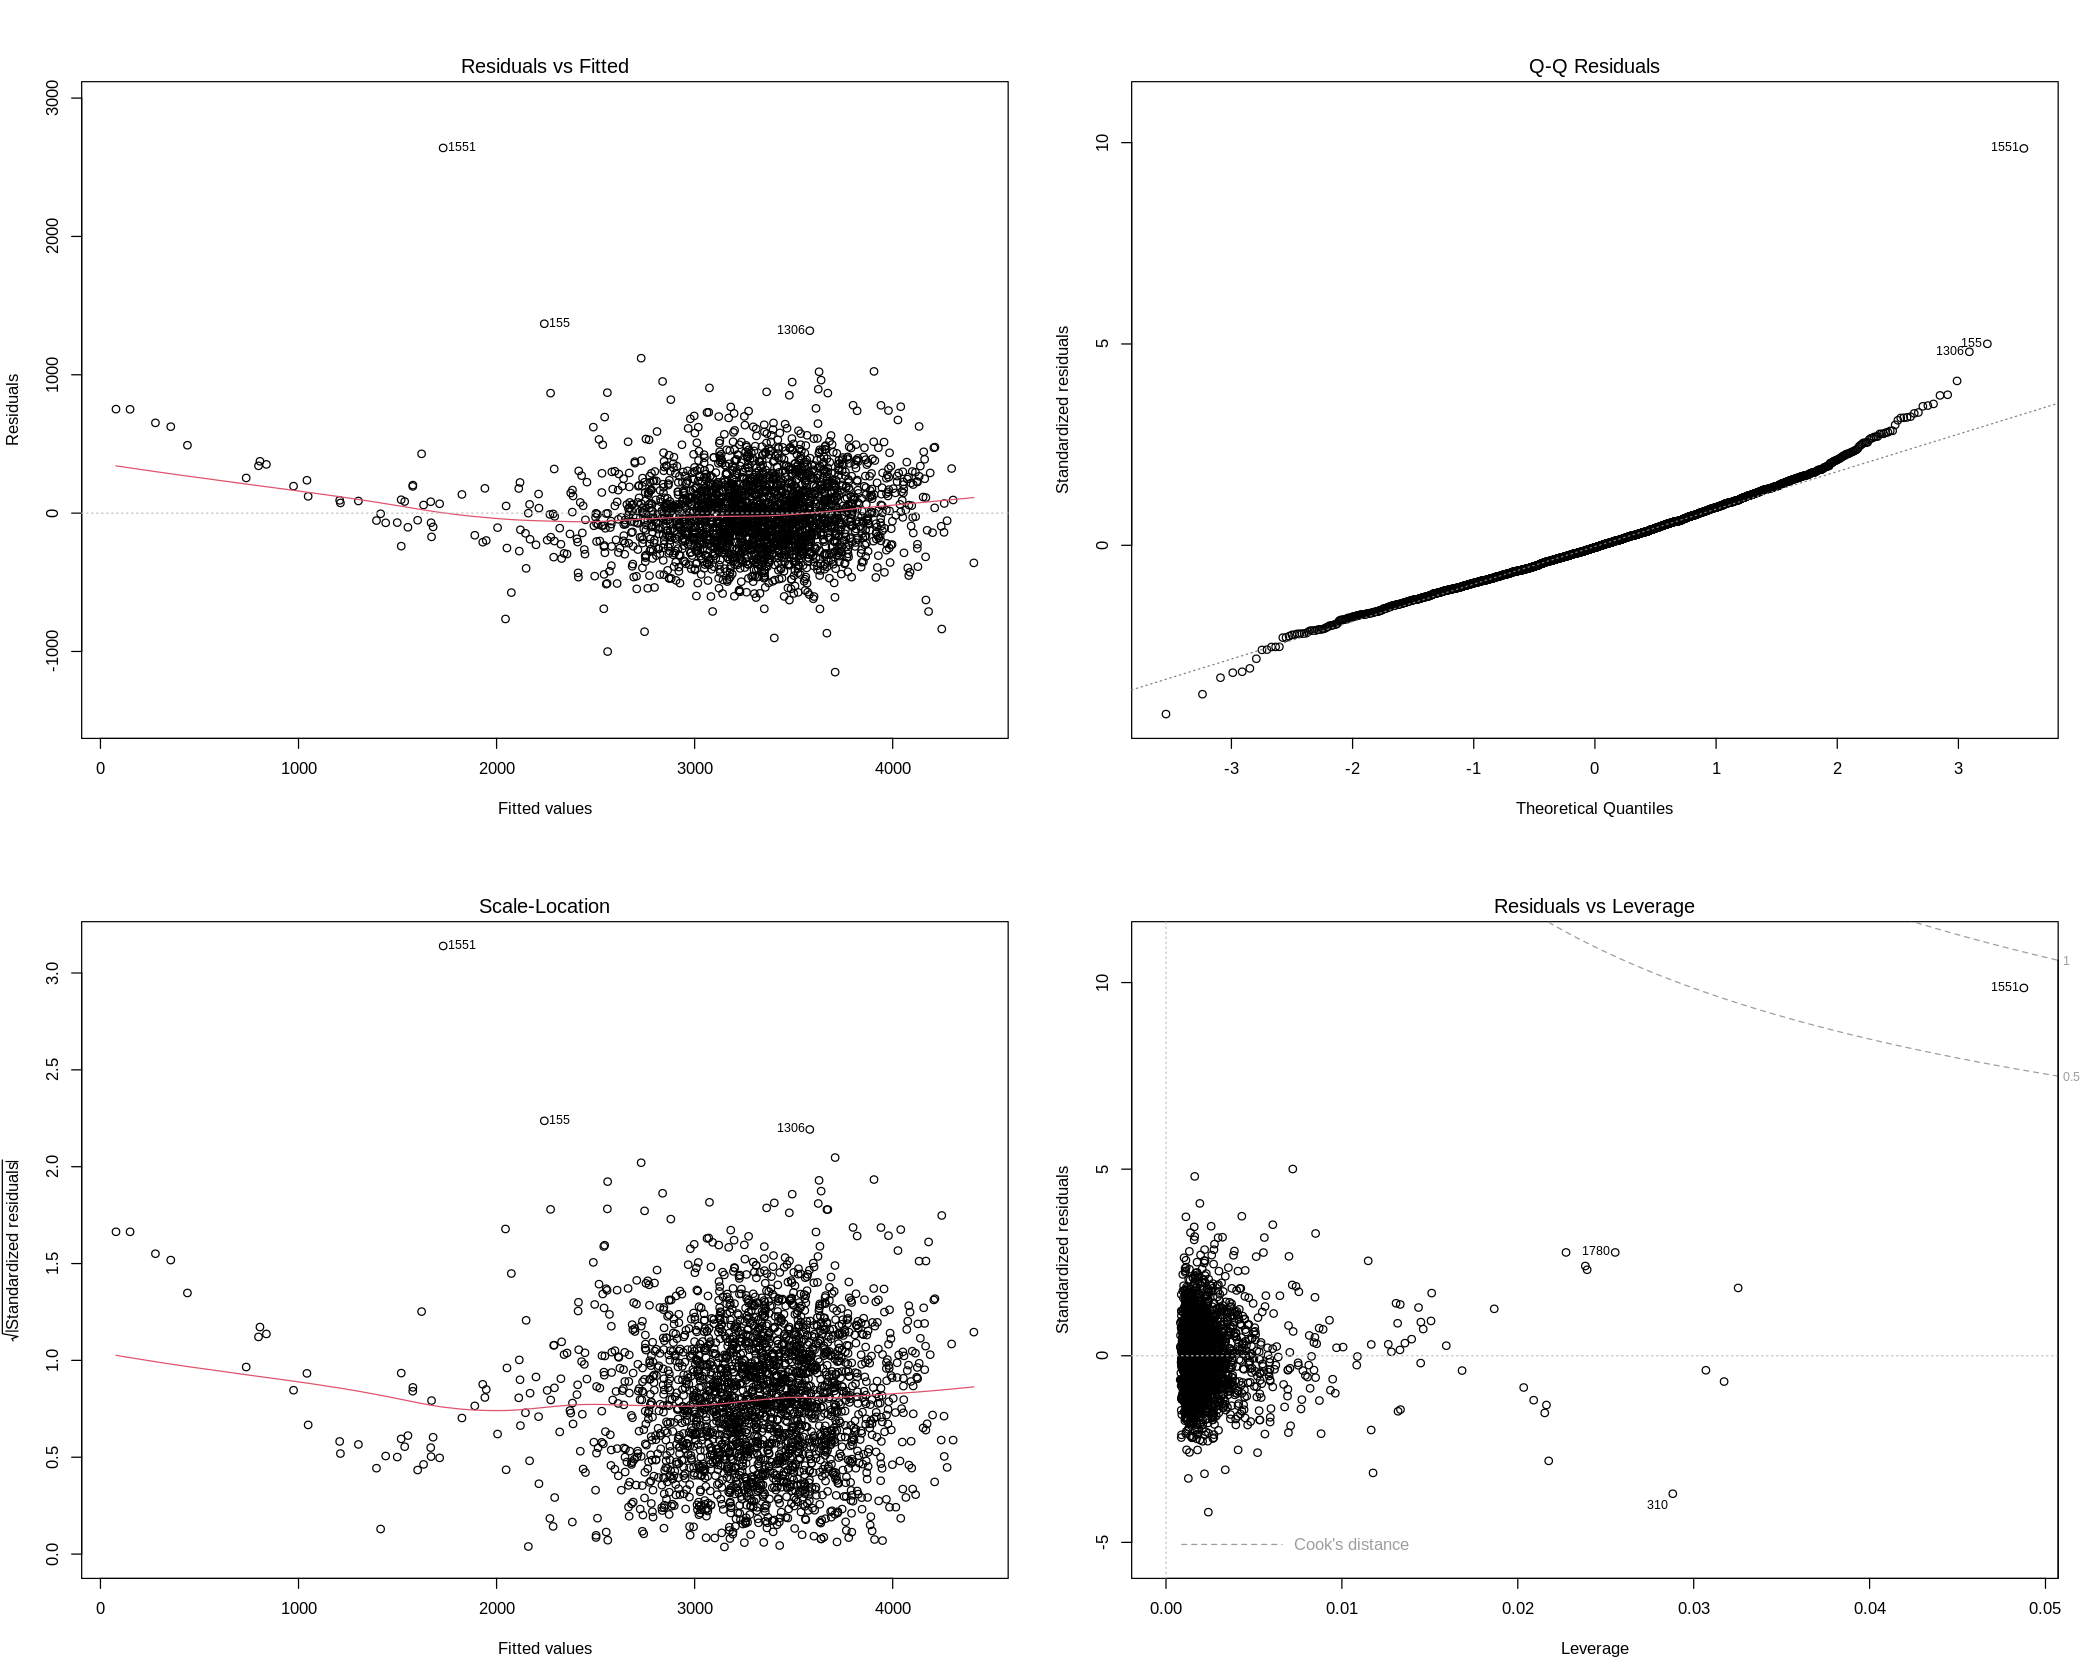

In [74]:
par(mfrow=c(2,2))

plot(model2)

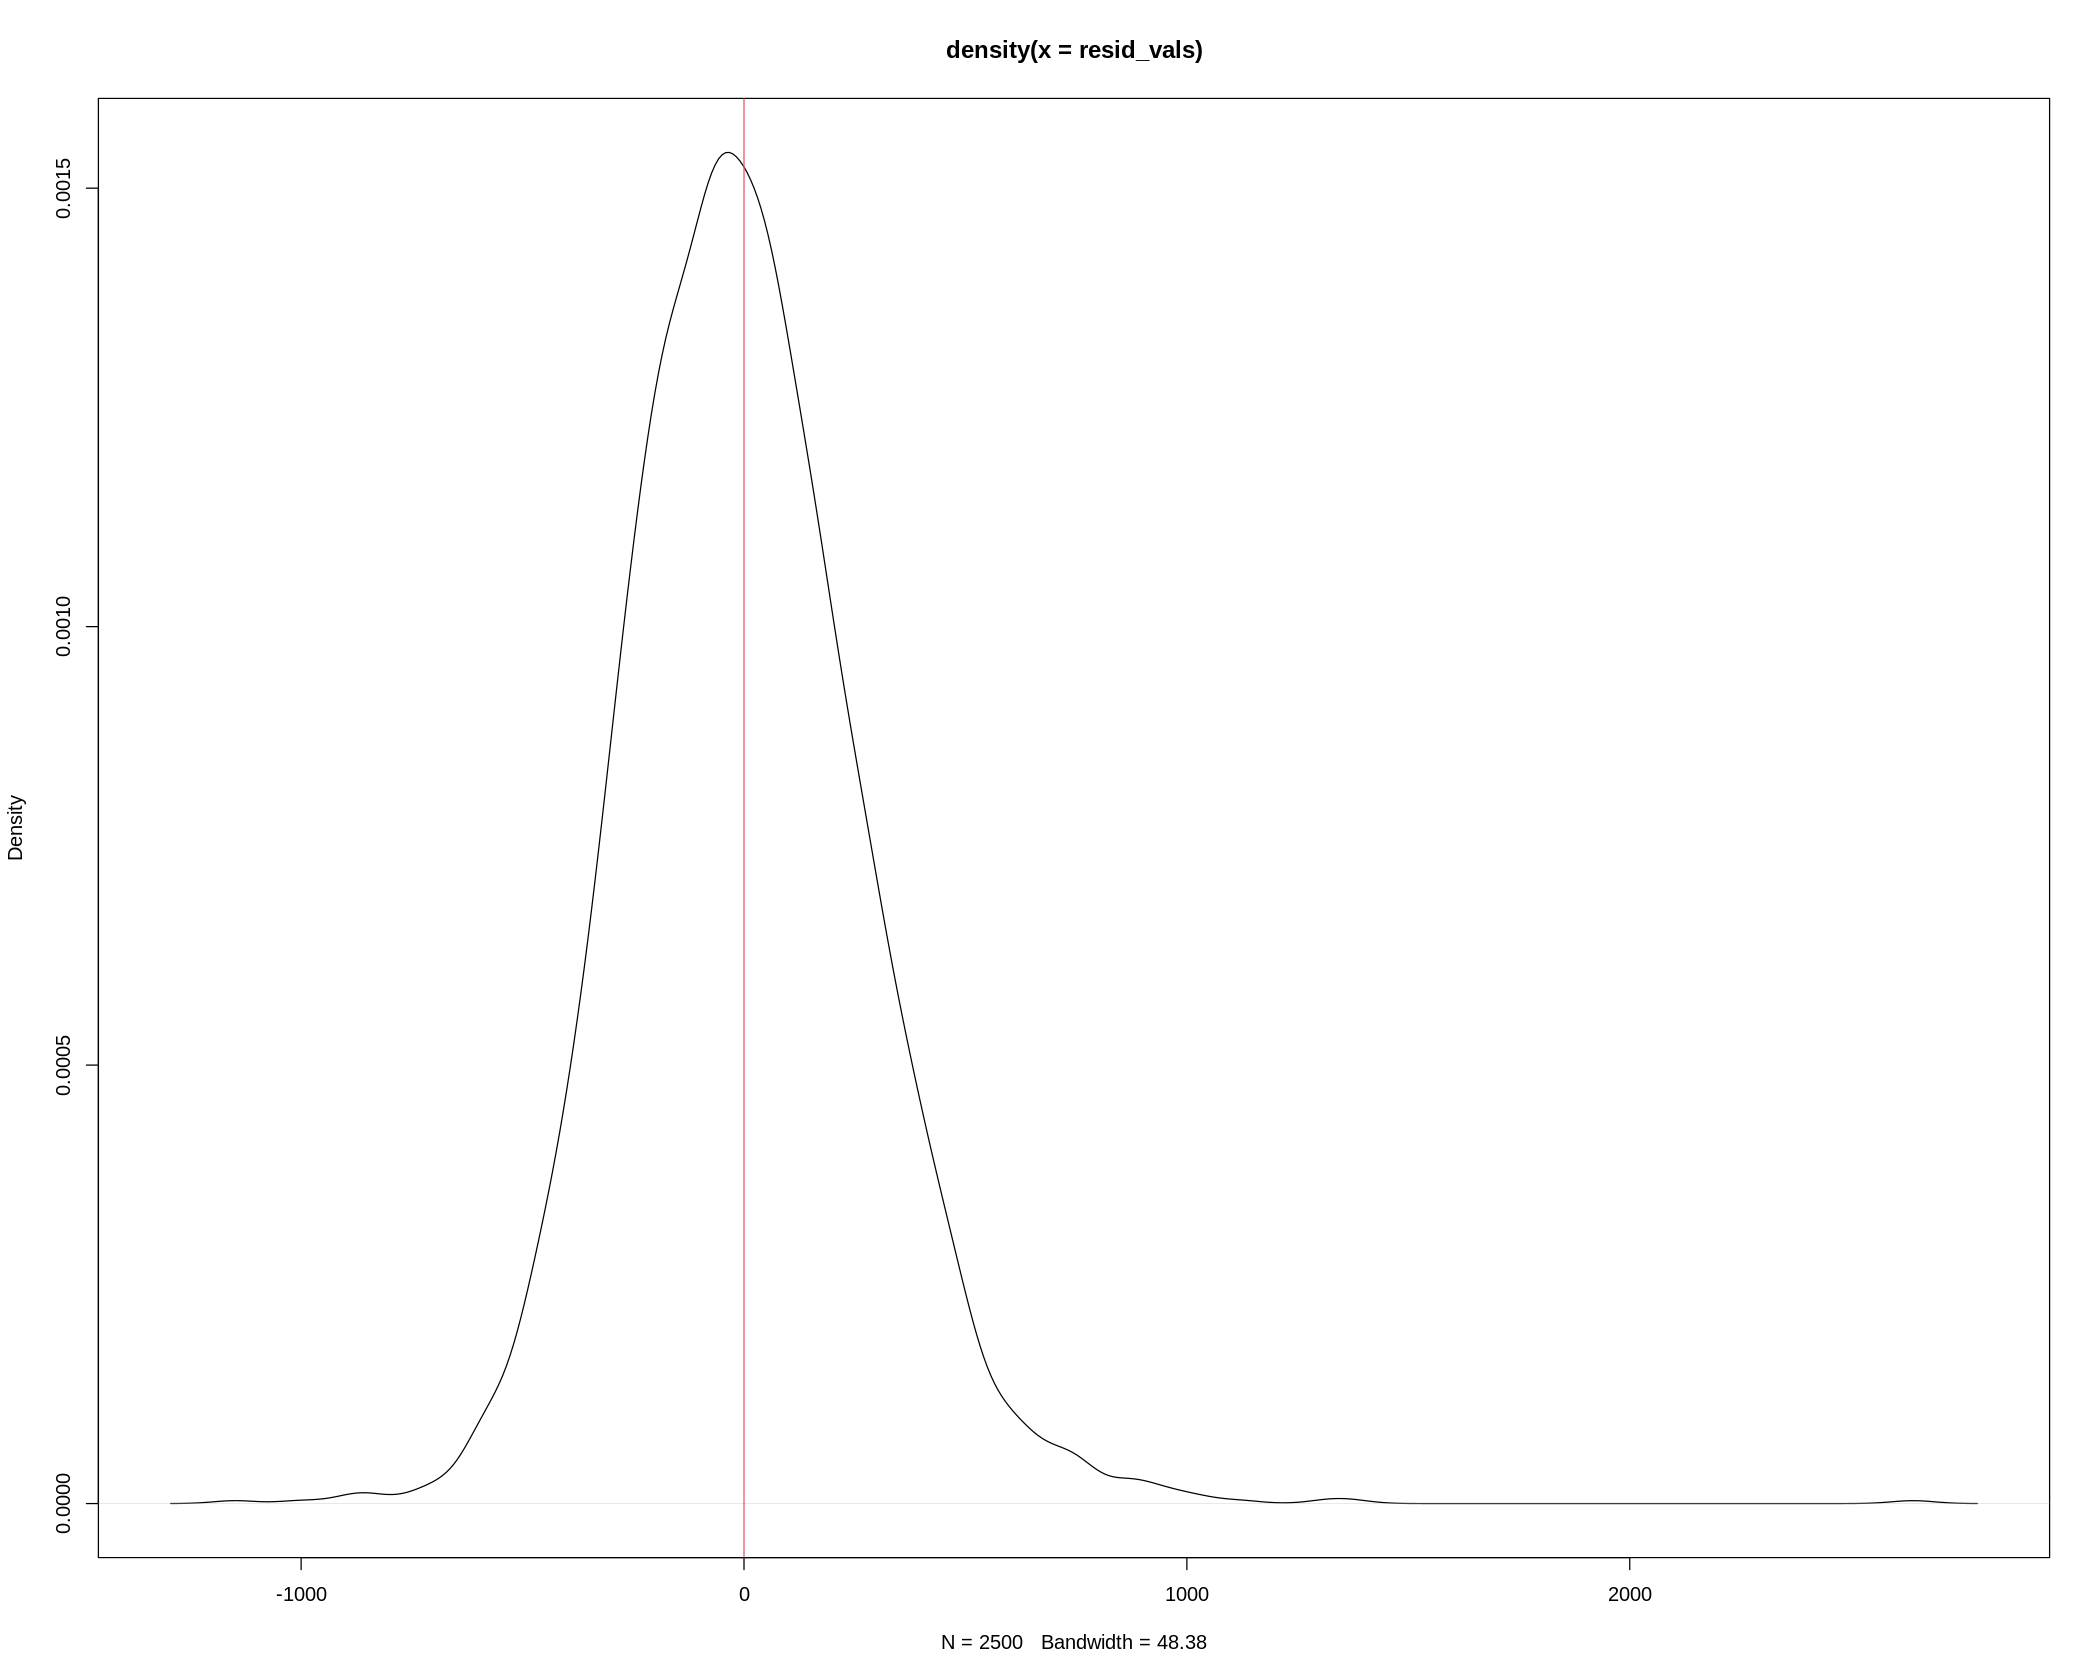

In [75]:
resid_vals = residuals(model2)
dens = density(resid_vals)
plot(dens)

abline(v = mean(resid_vals), col = 2)

- **Residuals vs Fitted**  
  Most points are distributed around the mean, with a slightly curved pattern, especially in the left tail. This means that the model does not fully capture the structure of the data because a purely linear relationship is not sufficient to reproduce the actual relationship among the data. Three observations are farther from the mean, particularly observation 1551;

- **Q-Q residuals**  
  Most points lie on the reference line, except for observations 1551, 155, and 1306, which are also the points farthest from the mean in the Residuals vs Fitted plot;

- **Scale-Location**  
  The plot used to assess the variance shows a slightly curved pattern, more pronounced in the left tail, with the three previously identified observations appearing farther away. This may raise doubts about the homoscedasticity of the model;

- **Residuals vs Leverage**  
  Observation 1551 exceeds the 0.5 Cook's distance threshold, indicating that it deserves attention, as it is also very close to the threshold of 1.

- **Residual Distribution**  
  The residuals are not normally distributed, mainly because of the right tail.

### Quantitative analysis

#### Shapiro test

In [76]:
shapiro.test(residuals(model2))


	Shapiro-Wilk normality test

data:  residuals(model2)
W = 0.97408, p-value < 2.2e-16


The result leads us to reject the null hypothesis of normality of the residual distribution, as already suggested by the graphical analysis.

#### Breusch-Pagan test

In [77]:
bptest(model2)


	studentized Breusch-Pagan test

data:  model2
BP = 90.253, df = 5, p-value < 2.2e-16


The result leads us to reject the null hypothesis of homoscedasticity, as already suggested by the Scale-Location plot.

Because heteroscedasticity can make the conventional standard errors of the OLS model unreliable and, consequently, affect the corresponding significance tests, heteroscedasticity-robust standard errors are calculated using the HC3 estimator. This correction does not change the coefficients estimated by the model, but provides an estimate of uncertainty that does not require the assumption of constant error variance.

In [78]:
# HETEROSCEDASTICITY-ROBUST STANDARD ERRORS

robust_vcov = vcovHC(
  model2,
  type = "HC3"
)

robust_test = coeftest(
  model2,
  vcov. = robust_vcov
)

robust_test


t test of coefficients:

                Estimate  Std. Error  t value  Pr(>|t|)    
(Intercept)  -6681.14450   167.67708 -39.8453 < 2.2e-16 ***
N.gravidanze    12.47497     4.63383   2.6921  0.007147 ** 
Gestazione      32.33206     5.26581   6.1400 9.573e-10 ***
Lunghezza       10.24857     0.73587  13.9271 < 2.2e-16 ***
Cranio          10.54020     0.80312  13.1241 < 2.2e-16 ***
SessoM          77.99271    11.08633   7.0350 2.563e-12 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


Using robust standard errors increases the uncertainty associated especially with the coefficients of “Gestazione”, “Lunghezza”, and “Cranio”. However, all variables retain their statistical significance: even “N.gravidanze”, which has the highest p-value, remains significant at the 1% level. The presence of heteroscedasticity therefore does not change the main inferential conclusions regarding the model coefficients.

In [79]:
# HETEROSCEDASTICITY-ROBUST CONFIDENCE INTERVALS

robust_vcov = sandwich::vcovHC(
  model2,
  type = "HC3"
)

robust_ci = lmtest::coefci(
  model2,
  vcov. = robust_vcov
)

round(robust_ci,2)

,2.5 %,97.5 %
(Intercept),-7009.95,-6352.34
N.gravidanze,3.39,21.56
Gestazione,22.01,42.66
Lunghezza,8.81,11.69
Cranio,8.97,12.12
SessoM,56.25,99.73


The robust 95% confidence intervals confirm the results obtained with HC3 standard errors: for all regressors, the intervals do not include zero, confirming the statistical significance of the coefficients even after the correction for heteroscedasticity.

#### Durbin-Watson test

In [80]:
dwtest(model2)


	Durbin-Watson test

data:  model2
DW = 1.9535, p-value = 0.1224
alternative hypothesis: true autocorrelation is greater than 0


The results lead us not to reject the null hypothesis of error independence.

## 3.4 Influential Observation Analysis

### Leverage

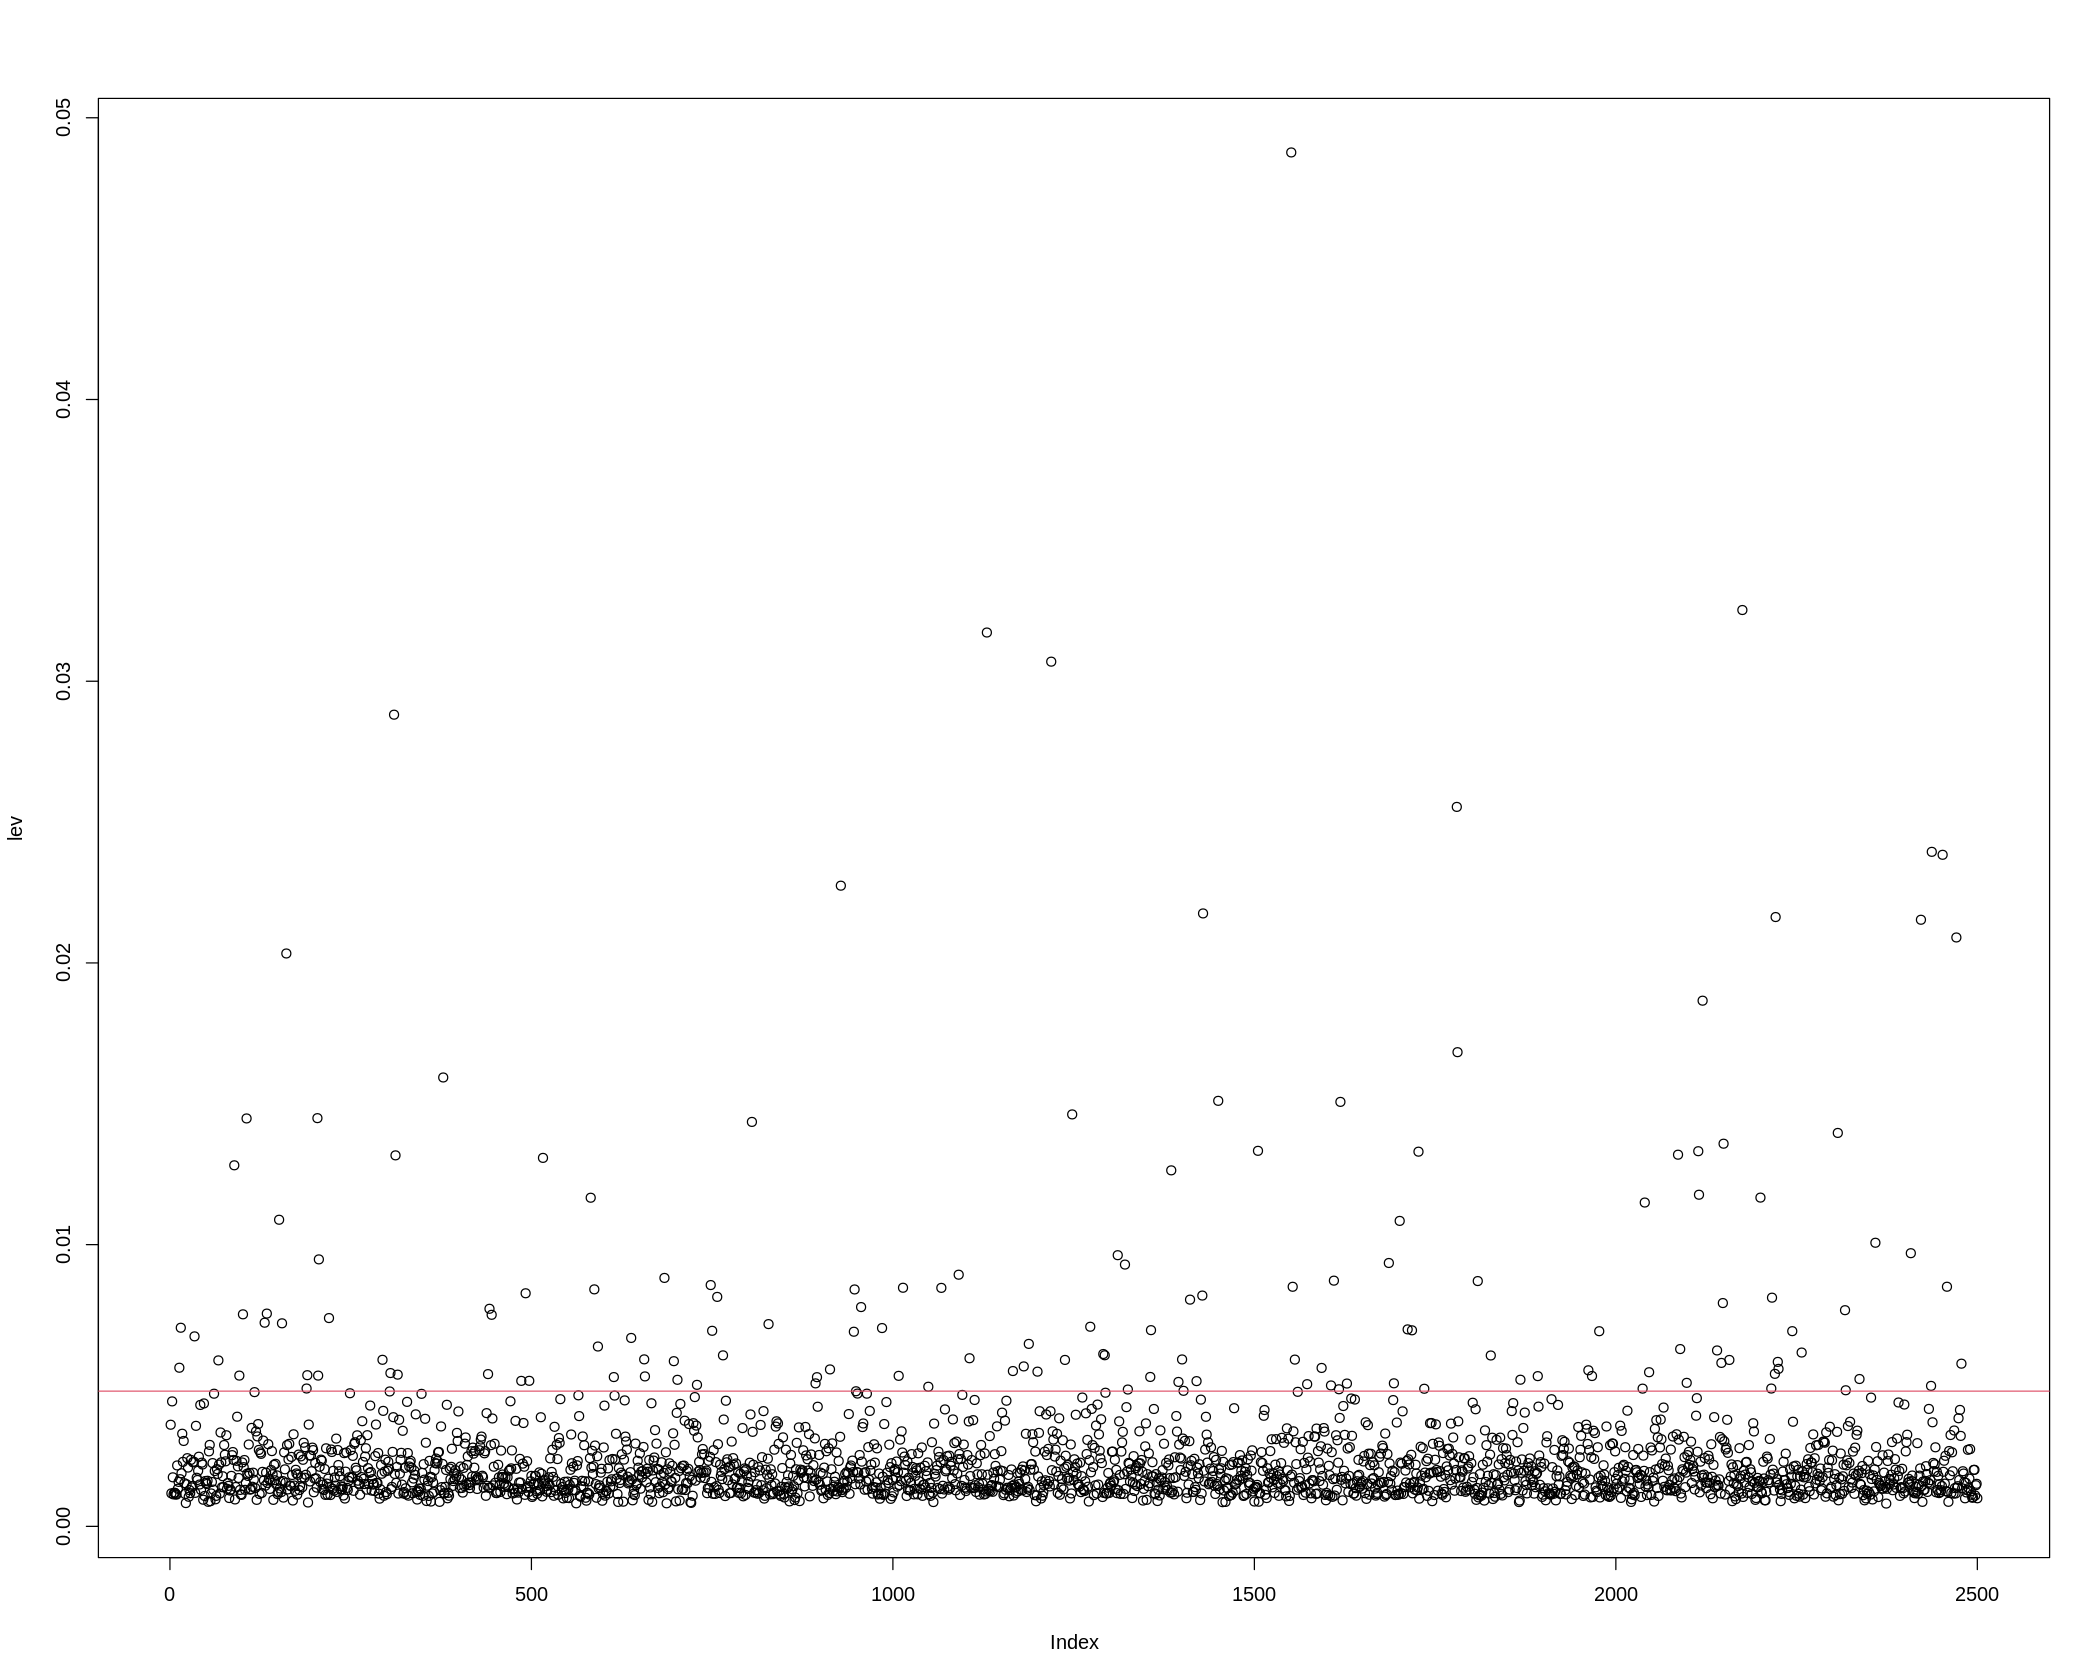

In [82]:
lev = hatvalues(model2)
plot(lev)
p = sum(lev)
threshold.lev = 2 *p/N
abline(h=threshold.lev, col = 2)

There are many observations with relatively high leverage values. The most distant ones are probably the same observations already identified as anomalous in the other tests: 1551, 155, and 1306. The most distant observation is reasonably expected to be 1551.

### Outliers

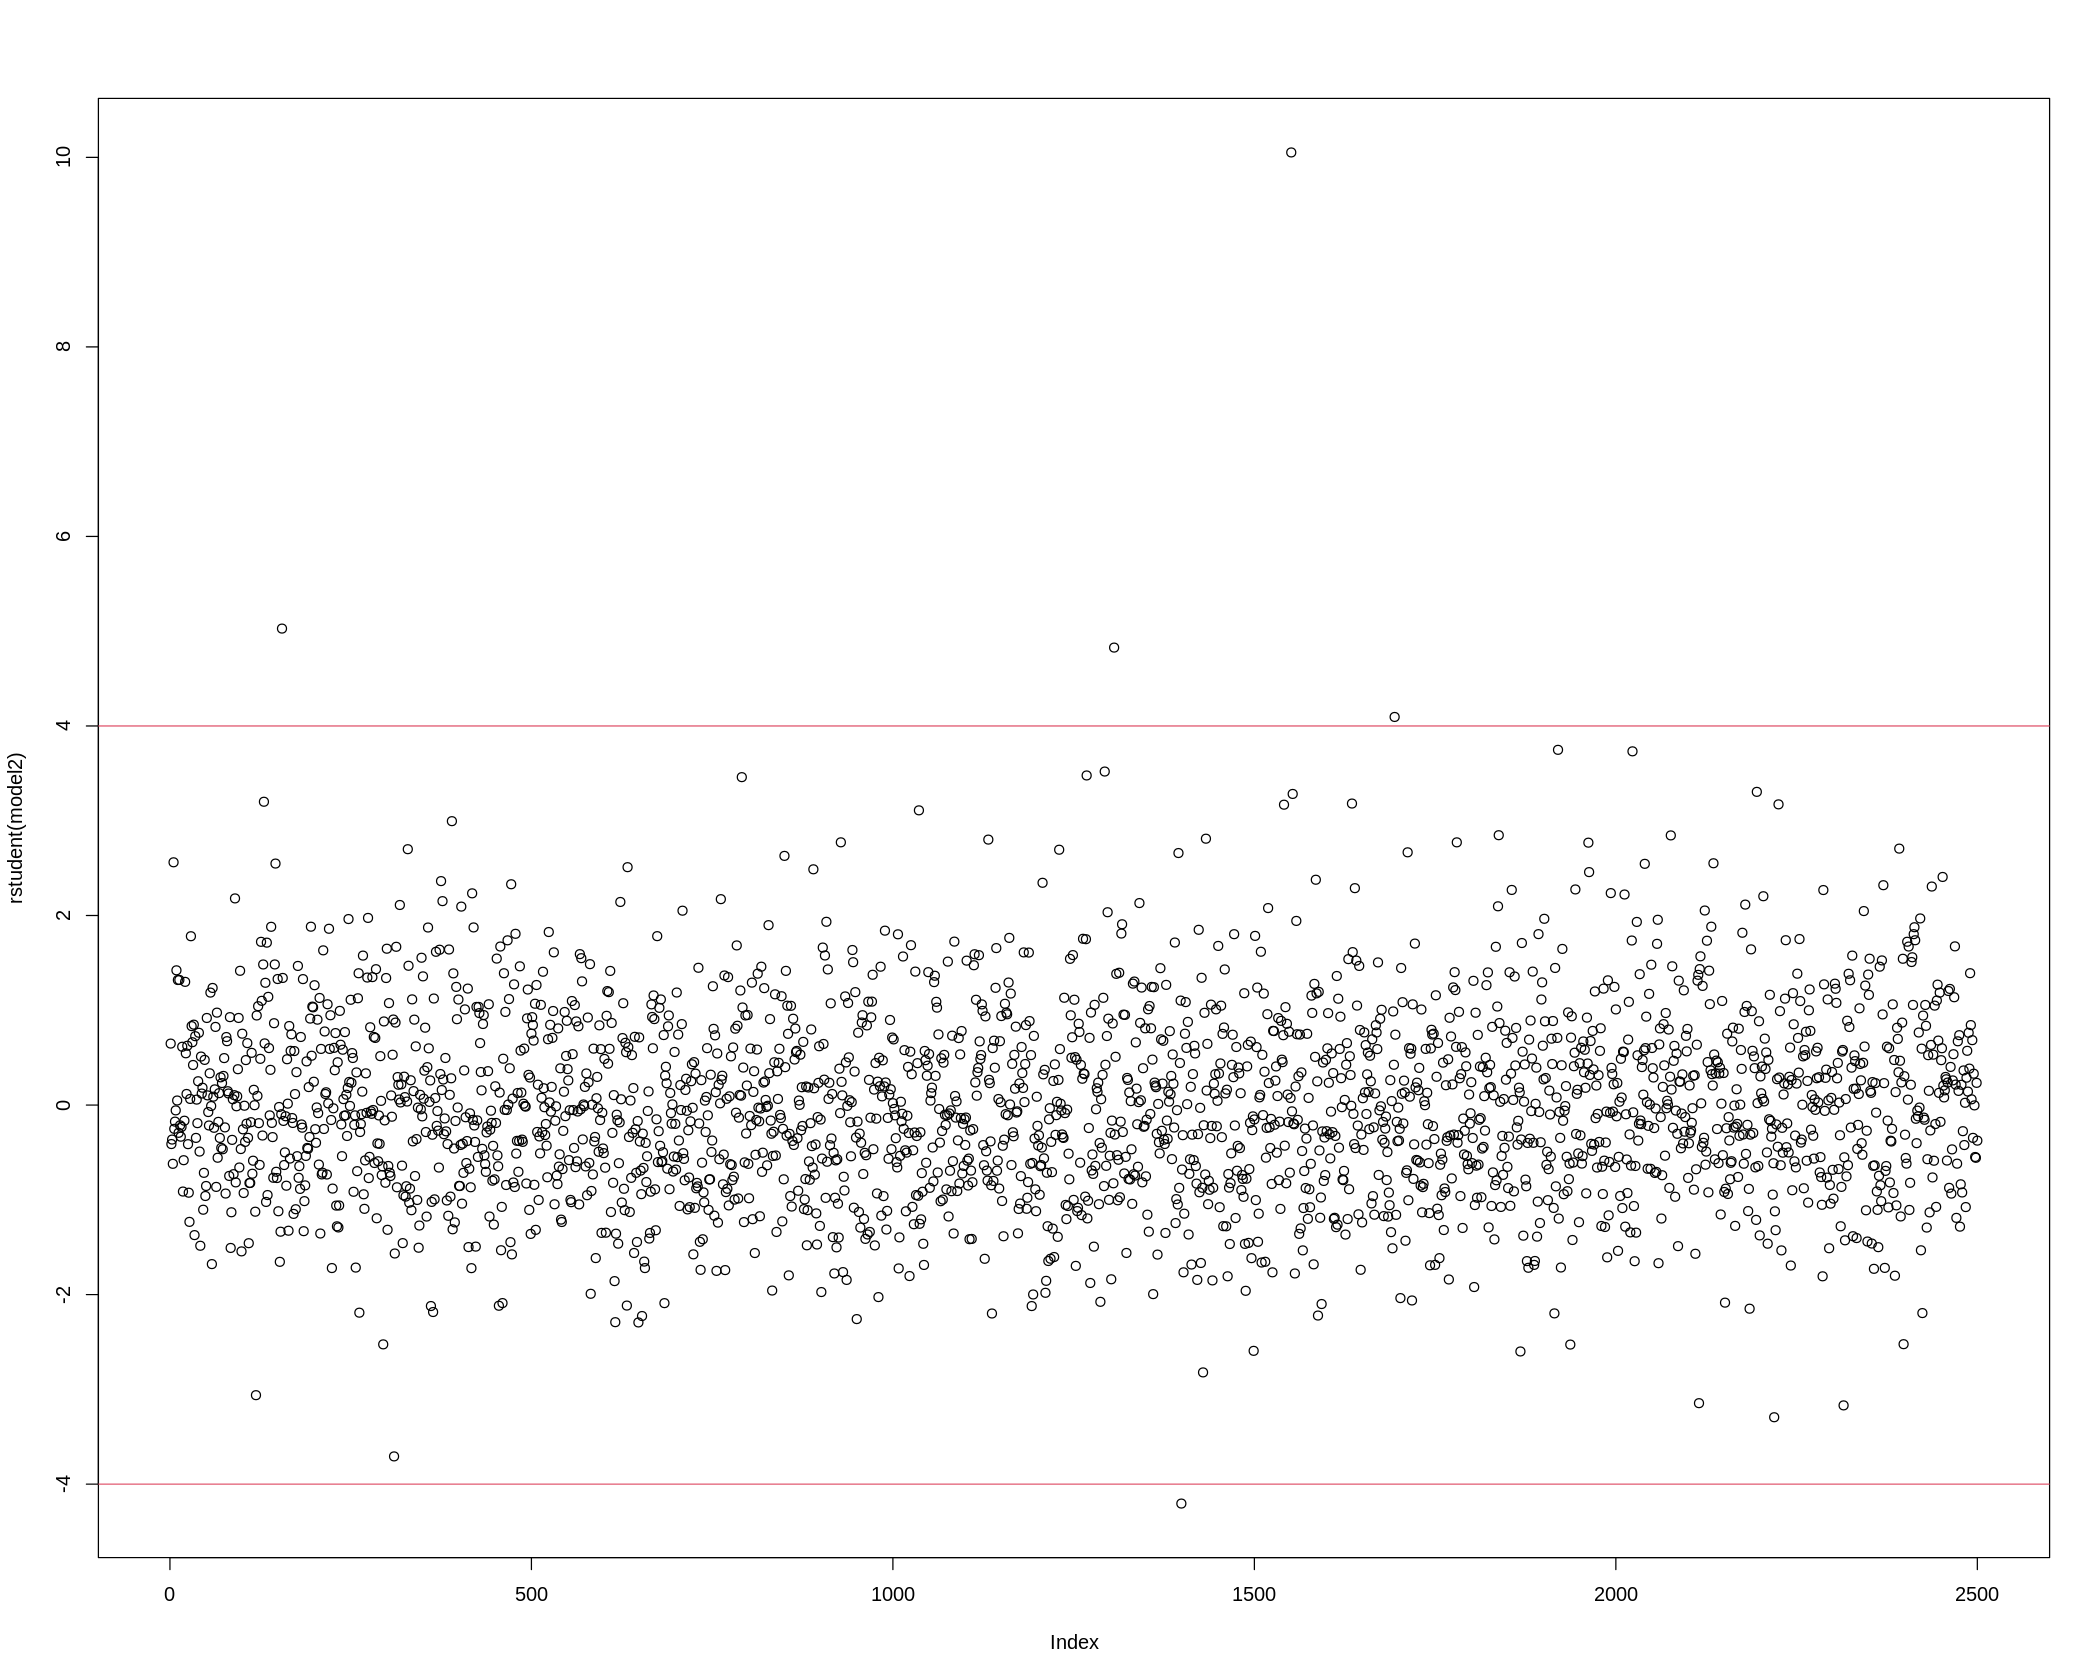

In [83]:
plot(rstudent(model2))
abline(h=c(-4,4), col=2)

In [84]:
out.t = outlierTest(model2)
kable(out.t$rstudent)



|     |         x|
|:----|---------:|
|1551 | 10.051908|
|155  |  5.027798|
|1306 |  4.827238|

The three anomalous observations identified previously are confirmed, with observation #1551 being the most anomalous of the three.

### Cook's Distance

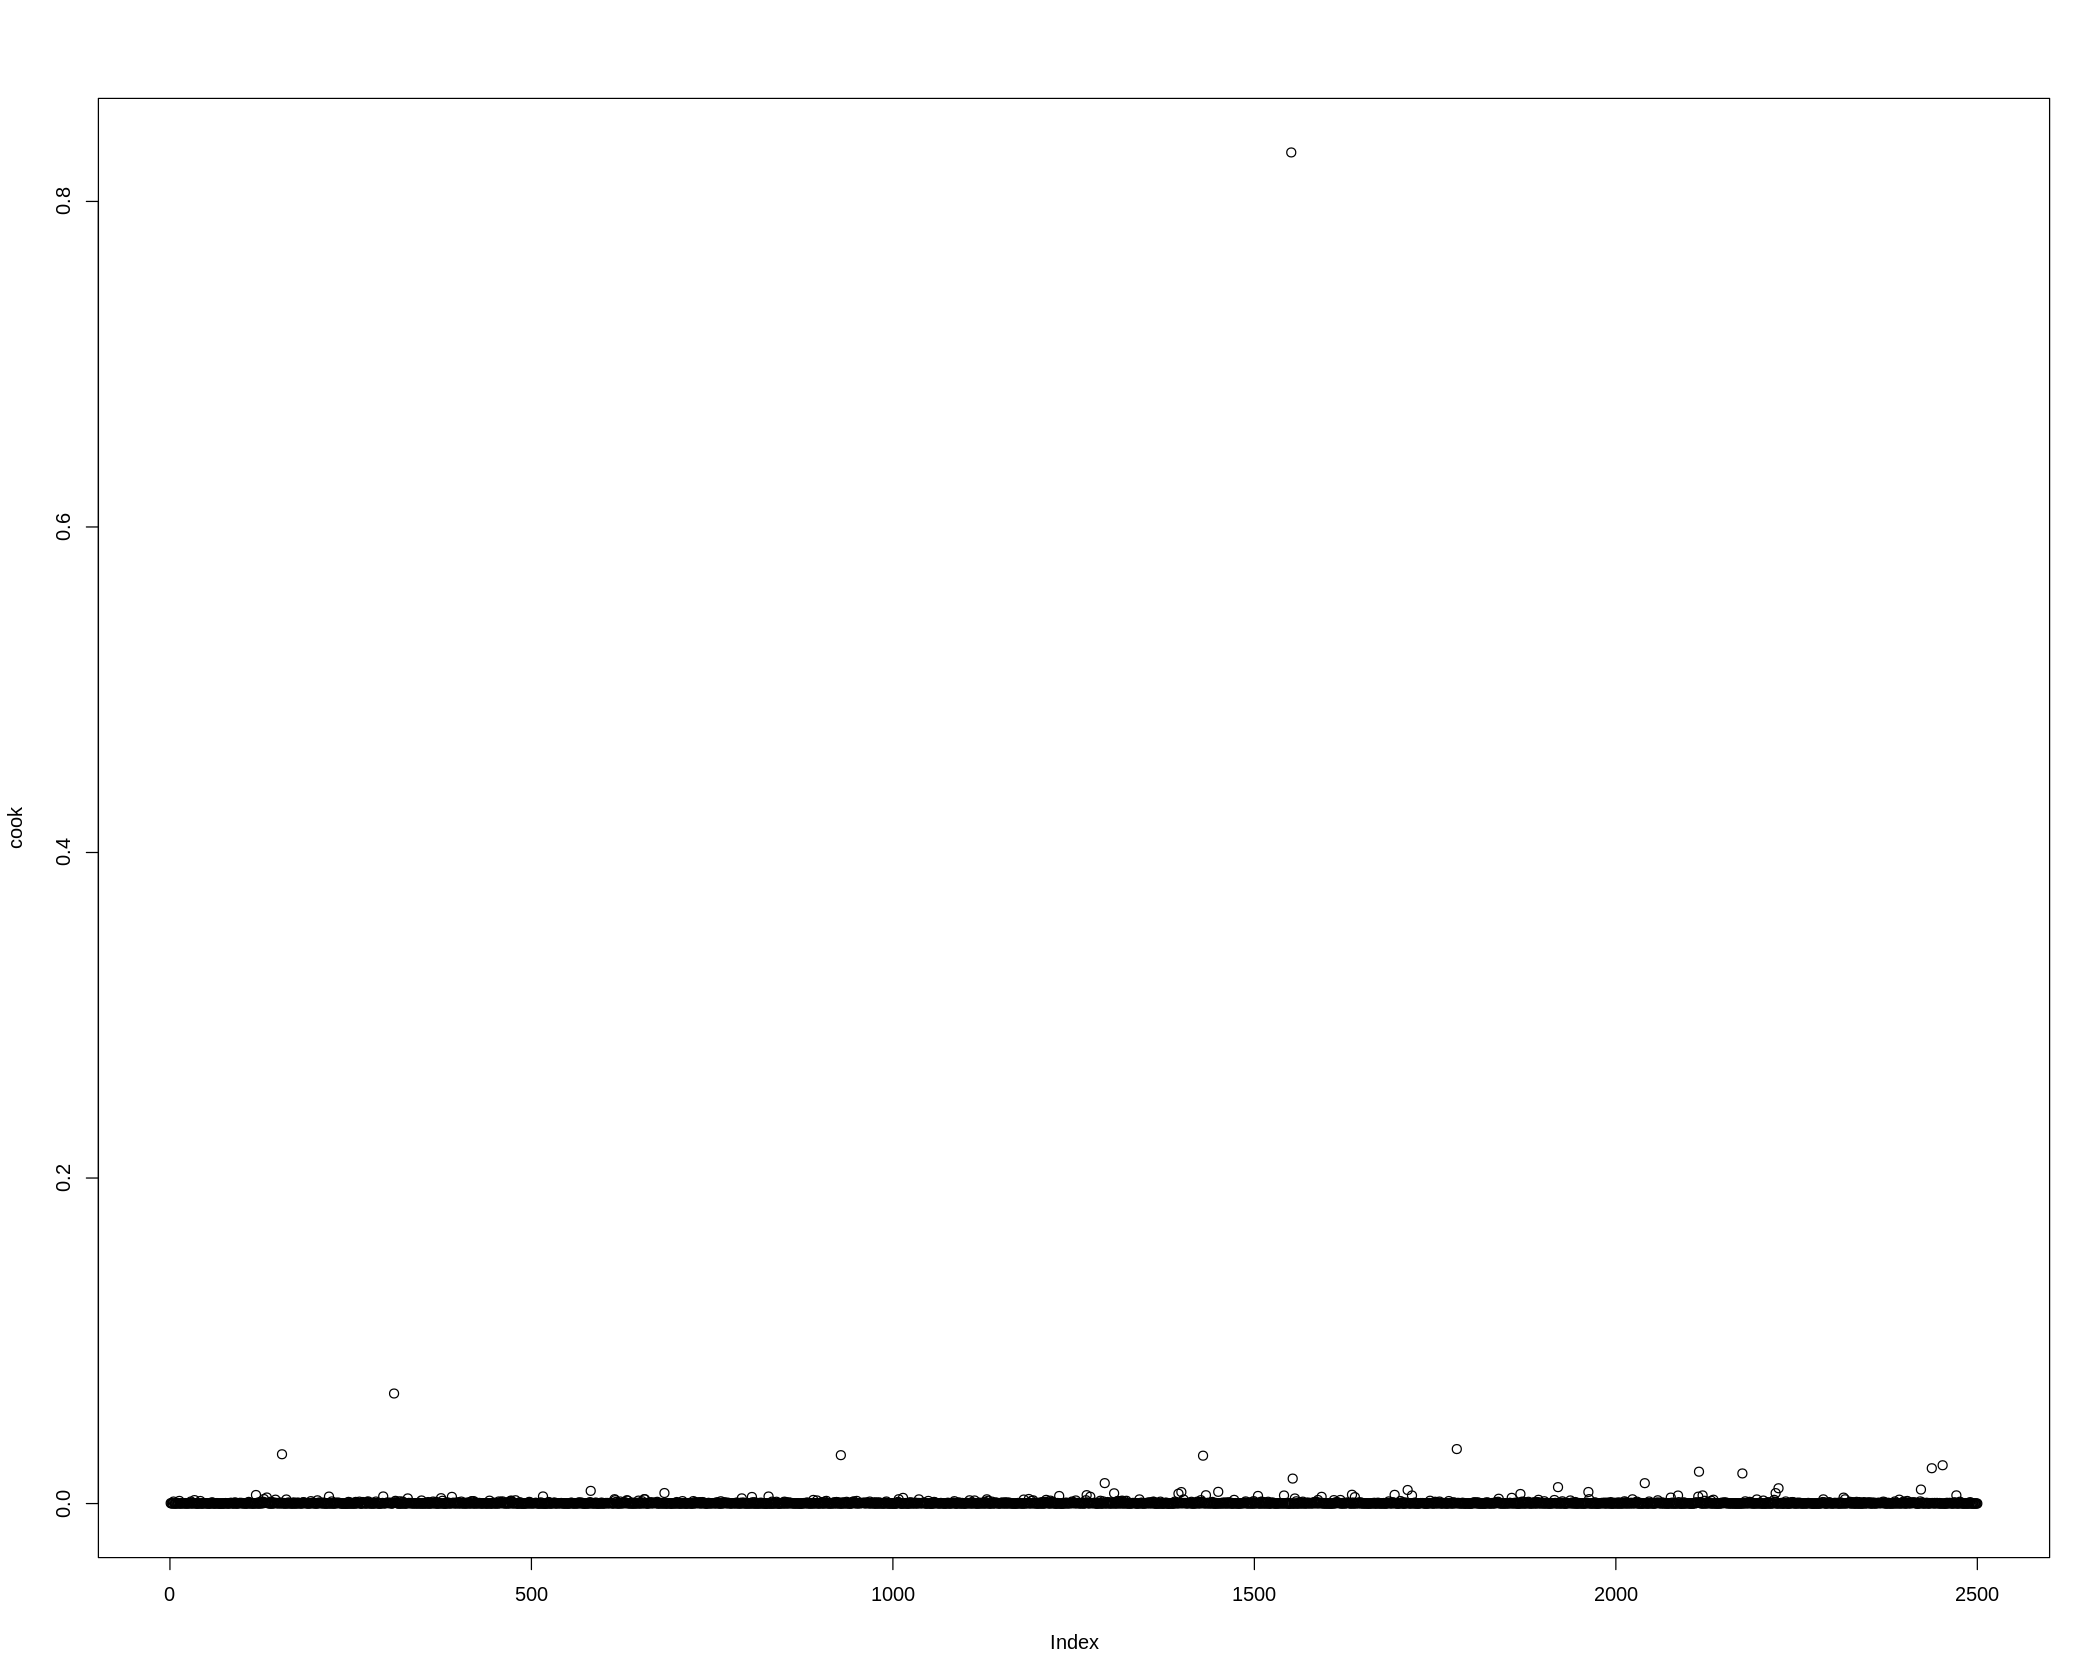

In [85]:
cook=cooks.distance(model2)
plot(cook)

In [86]:
max_index = which.max(cook)
max_value = cook[max_index]

cook_table = data.frame(
  "Observation" = max_index,
  "Cook's Distance" = round(max_value, 2)
)

kable(cook_table, caption = "Observation with Maximum Cook's Distance")



Table: Observation with Maximum Cook's Distance

|     | Observation| Cook.s.Distance|
|:----|-----------:|---------------:|
|1551 |        1551|            0.83|

The most concerning observation is 1551. This value exceeds the threshold of 0.5 and lies between this threshold and the threshold of 1, with a Cook's distance of 0.77.

The observation in question is a female newborn weighing 4370 g, with a height of 315 mm and a cranial diameter of 374 mm. The anomaly is probably due to a weight almost 40% above the female mean (3161 g), combined with a length of 315 mm, which is more than 35% below the female mean (490 mm). The discrepancy increases further when considering only females in that weight range, whose length is at least 500 mm.

The most plausible hypothesis is a data-entry error in one of the two measurements. Among newborns weighing at least 4000 g, length never falls below 450 mm (for either males or females); whereas among newborns with a length between 300 mm and 400 mm, only one case exceeds 2000 g, with weights ranging from 830 g to 1780 g.

# 4. Predictions and Results

Once the model has been validated, we will use it to make practical predictions. For example, we can estimate the weight of a female newborn for a mother in her third pregnancy who will give birth at the 39th week of gestation.

In [87]:
model2


Call:
lm(formula = Peso ~ N.gravidanze + Gestazione + Lunghezza + Cranio + 
    Sesso, data = nb_data)

Coefficients:
 (Intercept)  N.gravidanze    Gestazione     Lunghezza        Cranio  
    -6681.14         12.47         32.33         10.25         10.54  
      SessoM  
       77.99  


Holding the other variables constant, all estimated coefficients indicate a positive association with the expected mean newborn weight. Therefore, on average, each additional pregnancy is associated with an increase of approximately 12 g in expected newborn weight. An additional week of gestation is associated, on average, with an increase of approximately 32 g, while each additional millimeter of newborn length and cranial diameter is associated with an average increase of approximately 10 g. Finally, with respect to the qualitative variable “Sesso”, males have an expected weight that is, on average, approximately 78 g higher than females (baseline category).

## Prediction with "model2"

For the other variables, I use the mean values obtained from the dataset:

**Lunghezza = 495**  
**Cranio = 340**

In [88]:
kable(predict(model2,newdata = data.frame(
  N.gravidanze = 3,
  Gestazione = 39,
  Lunghezza = mean(nb_data$Lunghezza),
  Cranio = mean(nb_data$Cranio),
  Sesso = "F")))



|       x|
|-------:|
| 3271.09|

For a female profile with these characteristics, the model estimates an expected mean weight of approximately 3271 g.